# Trabajo Final · Unidad 1 — Diagnóstico y preparación de una serie de tiempo
**Materia:** Series de Tiempo Aplicadas a las Finanzas
**Serie:** Precio de cierre mensual de Rocket Lab USA, Inc. (Nasdaq: RKLB), en USD
**Integrantes:** _(completar nombres del equipo)_
**Fecha de consulta de la fuente:** 2 de octubre de 2026

> Este notebook sigue la estructura de las indicaciones del trabajo final (y de las Actividades 2 y 2-Parte II de Colab). Al final de cada sección hay una celda **«Respuestas»** con las respuestas a las preguntas, basadas en los números calculados arriba.
> El diagnóstico es **descriptivo**: no se prueba formalmente estacionariedad ni se estima ningún modelo. Las pruebas ADF y Ljung-Box se usan solo como apoyo orientativo.

## 1. Identificación y carga de datos

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titlesize": 13, "axes.titleweight": "bold"})
C_NIVEL, C_ALT, C_TEST, C_REF = "#1F4E79", "#C55A11", "#2E8B57", "#7F7F7F"

os.makedirs("figuras", exist_ok=True); os.makedirs("tablas", exist_ok=True)
R = {}                      # resultados que consumirá el reporte Word
MESES = ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"]
def fmt_fecha(ts):
    ts = pd.Timestamp(ts); return f"{MESES[ts.month-1]}-{ts.year}"
def guarda(fig, nombre):
    fig.tight_layout(); fig.savefig(f"figuras/{nombre}.png", dpi=150, bbox_inches="tight"); plt.show()
def eje_fechas(ax, paso=6):
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]) if paso == 6 else mdates.MonthLocator(interval=paso))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: fmt_fecha(mdates.num2date(x))))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
print("Librerías cargadas")

Librerías cargadas


In [2]:
# Carga del archivo. En Google Colab, si el CSV no está en la carpeta, se pide subirlo.
ARCHIVO = "Datos_historicos_RKLB.csv"
if not os.path.exists(ARCHIVO):
    from google.colab import files
    ARCHIVO = list(files.upload().keys())[0]

crudo = pd.read_csv(ARCHIVO, encoding="utf-8-sig")
print("Archivo:", ARCHIVO, "| filas x columnas:", crudo.shape)
print("\nPrimeras observaciones (tal como vienen en el archivo, orden descendente):")
display(crudo.head())
print("Últimas observaciones del archivo (las más antiguas):")
display(crudo.tail())

Archivo: Datos_historicos_RKLB.csv | filas x columnas: (49, 7)

Primeras observaciones (tal como vienen en el archivo, orden descendente):


,Fecha,Cierre,Apertura,Máximo,Mínimo,Vol.,% var.
0,01.10.2026,70.46,72.310,72.64,69.424,23.31M,1.12%
1,01.09.2026,69.68,62.240,75.46,60.510,425.69M,9.01%
2,01.08.2026,63.92,63.340,86.83,62.170,374.16M,-1.59%
3,01.07.2026,64.95,101.195,107.60,58.200,423.37M,-36.10%
4,01.06.2026,101.65,132.380,135.63,80.000,634.08M,-29.15%


Últimas observaciones del archivo (las más antiguas):


,Fecha,Cierre,Apertura,Máximo,Mínimo,Vol.,% var.
44,01.02.2023,4.50,4.90,5.47,4.380,75.90M,-9.46%
45,01.01.2023,4.97,3.85,5.68,3.775,73.09M,31.83%
46,01.12.2022,3.77,4.28,4.50,3.480,69.95M,-10.02%
47,01.11.2022,4.19,5.25,5.76,3.880,73.76M,-17.68%
48,01.10.2022,5.09,4.14,5.23,3.770,58.09M,25.06%


In [3]:
f = pd.to_datetime(crudo["Fecha"], format="%d.%m.%Y")
ident = pd.DataFrame({
    "Elemento": ["Variable analizada", "Qué representa una observación", "Unidades", "Frecuencia", "Periodo",
                 "Número de observaciones", "Fuente de los datos", "Mercado / emisor", "Fecha de consulta"],
    "Descripción": ["Precio de cierre de la acción de Rocket Lab USA, Inc. (columna «Cierre»)",
                    "Precio de cierre de la acción RKLB al final de un mes de negociación (la fecha es la etiqueta del mes, día 1)",
                    "Dólares estadounidenses por acción (USD)",
                    "Mensual",
                    f"{fmt_fecha(f.min())} a {fmt_fecha(f.max())}",
                    f"{len(crudo)} meses",
                    "Archivo «Datos históricos RKLB» (CSV) proporcionado por el equipo; formato de exportación tipo Investing.com (Fecha, Cierre, Apertura, Máximo, Mínimo, Vol., % var.). Enlace exacto: [completar]",
                    "Nasdaq (ticker RKLB)",
                    "2 de octubre de 2026"]})
ident.to_csv("tablas/t01_identificacion.csv", index=False)
display(ident.style.hide(axis="index"))

Elemento,Descripción
Variable analizada,"Precio de cierre de la acción de Rocket Lab USA, Inc. (columna «Cierre»)"
Qué representa una observación,"Precio de cierre de la acción RKLB al final de un mes de negociación (la fecha es la etiqueta del mes, día 1)"
Unidades,Dólares estadounidenses por acción (USD)
Frecuencia,Mensual
Periodo,oct-2022 a oct-2026
Número de observaciones,49 meses
Fuente de los datos,"Archivo «Datos históricos RKLB» (CSV) proporcionado por el equipo; formato de exportación tipo Investing.com (Fecha, Cierre, Apertura, Máximo, Mínimo, Vol., % var.). Enlace exacto: [completar]"
Mercado / emisor,Nasdaq (ticker RKLB)
Fecha de consulta,2 de octubre de 2026


### Respuestas

**¿Qué variable analizan y qué representa una observación?**  
La variable es el **precio de cierre de la acción de Rocket Lab USA, Inc. (Nasdaq: RKLB)**. Cada observación es el precio al que cerró la acción al final de un mes de negociación; la columna «Fecha» (día 1 de cada mes) funciona como etiqueta del mes. La base tiene 49 observaciones.

**¿En qué unidades se expresa?**  
En dólares estadounidenses (USD) por acción.

**¿Cuál es la fuente, periodo y frecuencia?**  
La fuente es el archivo CSV «Datos históricos RKLB» proporcionado por el equipo (con el formato de exportación tipo Investing.com: Fecha, Cierre, Apertura, Máximo, Mínimo, Vol., % var.); el enlace exacto debe completarse en el reporte. El periodo va de **oct-2022 a oct-2026**, con **frecuencia mensual**. La fecha de consulta es el 2 de octubre de 2026; por eso la última observación (oct-2026) corresponde a un mes todavía incompleto.

## 2. Revisión, limpieza y preparación

In [4]:
# Conversión de tipos: fecha (dd.mm.aaaa), números, volumen ("23.31M") y % var.
df = crudo.copy()
df["Fecha"] = pd.to_datetime(df["Fecha"], format="%d.%m.%Y")
for c in ["Cierre", "Apertura", "Máximo", "Mínimo"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df["Vol_M"] = df["Vol."].str.replace("M", "", regex=False).astype(float)          # millones de acciones negociadas en el mes
df["Var_pct_fuente"] = df["% var."].str.replace("%", "", regex=False).astype(float)  # % var. mensual que reporta la fuente
df = df.drop(columns=["Vol.", "% var."])

print("--- head() (antes de ordenar) ---"); display(df.head())
print("--- info() ---"); df.info()

--- head() (antes de ordenar) ---


,Fecha,Cierre,Apertura,Máximo,Mínimo,Vol_M,Var_pct_fuente
0,2026-10-01,70.46,72.310,72.64,69.424,23.31,1.12
1,2026-09-01,69.68,62.240,75.46,60.510,425.69,9.01
2,2026-08-01,63.92,63.340,86.83,62.170,374.16,-1.59
3,2026-07-01,64.95,101.195,107.60,58.200,423.37,-36.10
4,2026-06-01,101.65,132.380,135.63,80.000,634.08,-29.15


--- info() ---
<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Fecha           49 non-null     datetime64[us]
 1   Cierre          49 non-null     float64       
 2   Apertura        49 non-null     float64       
 3   Máximo          49 non-null     float64       
 4   Mínimo          49 non-null     float64       
 5   Vol_M           49 non-null     float64       
 6   Var_pct_fuente  49 non-null     float64       
dtypes: datetime64[us](1), float64(6)
memory usage: 2.8 KB


In [5]:
# Valores faltantes y duplicados
nulos = df.isnull().sum()
dup_filas = int(df.duplicated().sum()); dup_fechas = int(df["Fecha"].duplicated().sum())
print("Valores faltantes por columna:"); display(nulos.to_frame("nulos").T)
print("Filas duplicadas completas:", dup_filas, "| Fechas (meses) repetidas:", dup_fechas)

# Orden cronológico ascendente
df = df.sort_values("Fecha").reset_index(drop=True)
print("¿Fechas estrictamente crecientes y únicas?", df["Fecha"].is_monotonic_increasing and df["Fecha"].is_unique)

# Continuidad mensual: ¿falta algún mes entre el primero y el último?
calendario = pd.date_range(df["Fecha"].min(), df["Fecha"].max(), freq="MS")
faltan_meses = calendario.difference(df["Fecha"])
print(f"Meses del calendario en el periodo: {len(calendario)} | meses con dato: {len(df)} | meses faltantes: {len(faltan_meses)}")

# Las fechas son etiquetas «día 1 del mes». ¿Cuántas caen en sábado/domingo? (no son días de negociación, solo identifican el mes)
fin_semana = df[df["Fecha"].dt.dayofweek >= 5]
print(f"Etiquetas de mes que caen en sábado/domingo: {len(fin_semana)} de {len(df)} -> se interpretan como mes, no como día de cotización")
print("¿Algún mes repetido por fin de semana/feriado?", dup_fechas > 0)

# Consistencia interna: % var. de la fuente vs cambio calculado con el cierre (la 1ª fila no tiene previo)
calc = df["Cierre"].pct_change() * 100
dif_max = (calc - df["Var_pct_fuente"]).abs().max()
print(f"Máxima discrepancia entre «% var.» de la fuente y el cambio calculado: {dif_max:.4f} puntos porcentuales")
print("Cierre dentro de [Mínimo, Máximo] en todas las filas:", bool(((df["Cierre"] >= df["Mínimo"]) & (df["Cierre"] <= df["Máximo"])).all()))

# Mes en curso: la última fila (oct-2026) corresponde a un mes incompleto (consulta: 2-oct-2026)
vol_med = df["Vol_M"].iloc[:-1].median()
print(f"\nÚltima fila: {fmt_fecha(df['Fecha'].iloc[-1])} | volumen {df['Vol_M'].iloc[-1]:.2f} M vs. mediana mensual del resto {vol_med:.1f} M "
      f"({df['Vol_M'].iloc[-1]/vol_med*100:.1f} %) -> mes parcial")

serie = df.set_index("Fecha")["Cierre"].rename("Cierre (USD)")
serie.index.freq = "MS"
R.update(n=len(df), ini=str(df["Fecha"].min().date()), fin=str(df["Fecha"].max().date()), nulos=int(nulos.sum()),
         dup_filas=dup_filas, dup_fechas=dup_fechas, n_finsem=len(fin_semana), n_meses_cal=len(calendario), faltan=len(faltan_meses),
         dif_max_pct=float(dif_max), vol_ult=float(df["Vol_M"].iloc[-1]), vol_med_resto=float(vol_med))
display(df.head())

Valores faltantes por columna:


,Fecha,Cierre,Apertura,Máximo,Mínimo,Vol_M,Var_pct_fuente
nulos,0,0,0,0,0,0,0


Filas duplicadas completas: 0 | Fechas (meses) repetidas: 0
¿Fechas estrictamente crecientes y únicas? True
Meses del calendario en el periodo: 49 | meses con dato: 49 | meses faltantes: 0
Etiquetas de mes que caen en sábado/domingo: 15 de 49 -> se interpretan como mes, no como día de cotización
¿Algún mes repetido por fin de semana/feriado? False
Máxima discrepancia entre «% var.» de la fuente y el cambio calculado: 0.0049 puntos porcentuales
Cierre dentro de [Mínimo, Máximo] en todas las filas: True

Última fila: oct-2026 | volumen 23.31 M vs. mediana mensual del resto 308.4 M (7.6 %) -> mes parcial


,Fecha,Cierre,Apertura,Máximo,Mínimo,Vol_M,Var_pct_fuente
0,2022-10-01,5.09,4.14,5.23,3.770,58.09,25.06
1,2022-11-01,4.19,5.25,5.76,3.880,73.76,-17.68
2,2022-12-01,3.77,4.28,4.50,3.480,69.95,-10.02
3,2023-01-01,4.97,3.85,5.68,3.775,73.09,31.83
4,2023-02-01,4.50,4.90,5.47,4.380,75.90,-9.46


In [6]:
# Decisión sobre el mes parcial: se CONSERVA (es el dato más reciente disponible) y se verifica la sensibilidad más adelante (sección 13).
# Base limpia y ordenada (entregable de datos)
base = df.set_index("Fecha"); base.index.name = "Fecha"
base.round(4).to_csv("RKLB_base_limpia.csv")
print("Base limpia guardada:", base.shape)

Base limpia guardada: (49, 6)


### Respuestas

**¿Existen faltantes o duplicados?**  
No. Hay 0 valores faltantes en las 7 columnas, 0 filas duplicadas y 0 meses repetidos. Además, el «% var.» que reporta la fuente coincide con el cambio porcentual calculado a partir del cierre (discrepancia máxima de 0.0049 puntos porcentuales, solo por redondeo) y el cierre está siempre entre el mínimo y el máximo del mes.

**¿Qué decisión tomaron y por qué?**  
(1) Convertir «Fecha» (formato dd.mm.aaaa) a *datetime* y **ordenar de forma ascendente**, porque el archivo venía del más reciente al más antiguo y los rezagos y diferencias requieren orden cronológico. (2) Convertir «Vol.» (por ejemplo «23.31M») y «% var.» a números. (3) **No imputar ni eliminar nada**, porque no hay faltantes ni duplicados. (4) **Conservar oct-2026** aunque sea un mes parcial (su volumen es de 23.31 M de acciones, solo 7.6 % de la mediana mensual de 308.4 M), por ser el dato más reciente; se verificó que no cambia el diagnóstico: la autocorrelación de rezago 1 del cambio logarítmico es 0.035 sin ese mes y 0.034 con él.

**¿Hay observaciones repetidas por fines de semana o días no hábiles?**  
No. Los 49 meses del calendario entre oct-2022 y oct-2026 tienen exactamente un dato (0 meses faltantes y 0 repetidos). Como la serie es mensual, la fecha es solo la etiqueta del mes (día 1): 15 de las 49 etiquetas caen en sábado o domingo (por ejemplo, 01-oct-2022 fue sábado), pero eso no genera repeticiones ni huecos, porque el dato es el precio de cierre del mes y no el de ese día.

## 3. Serie en nivel

In [7]:
desc = serie.describe().to_frame("Cierre (USD)").T
desc["varianza"] = serie.var(); desc["coef. variación (%)"] = serie.std() / serie.mean() * 100
desc["asimetría"] = serie.skew(); desc["curtosis (exceso)"] = serie.kurt(); desc["rango"] = serie.max() - serie.min()
desc = desc.rename(columns={"count": "n", "mean": "media", "std": "desv. est.", "min": "mínimo", "25%": "Q1", "50%": "mediana", "75%": "Q3", "max": "máximo"})
desc.round(3).to_csv("tablas/t03_descriptiva_nivel.csv"); display(desc.round(3))
imax, imin = serie.idxmax(), serie.idxmin()
print(f"Máximo: {serie.max():.2f} USD en {fmt_fecha(imax)} | Mínimo: {serie.min():.2f} USD en {fmt_fecha(imin)}")
print(f"Primer cierre {serie.iloc[0]:.2f} ({fmt_fecha(serie.index[0])}) -> último {serie.iloc[-1]:.2f} ({fmt_fecha(serie.index[-1])}): {serie.iloc[-1]-serie.iloc[0]:+.2f} USD ({(serie.iloc[-1]/serie.iloc[0]-1)*100:+.1f}%)")
print(f"Caída desde el máximo ({fmt_fecha(imax)}) al último dato: {(serie.iloc[-1]/serie.max()-1)*100:.1f}%")

# Por año calendario: media, desviación y rango (¿la variabilidad es constante?)
por_anio = serie.groupby(serie.index.year).agg(n="size", media="mean", desv_est="std", minimo="min", maximo="max")
por_anio["coef_var_%"] = por_anio["desv_est"] / por_anio["media"] * 100
por_anio.round(2).to_csv("tablas/t03_por_anio.csv"); display(por_anio.round(2))
R["por_anio"] = por_anio.round(2).reset_index().rename(columns={"index": "anio", "Fecha": "anio"}).to_dict("records")

,n,media,desv. est.,mínimo,Q1,mediana,Q3,máximo,varianza,coef. variación (%),asimetría,curtosis (exceso),rango
Cierre (USD),49.0,29.868,32.608,3.76,4.585,10.7,48.6,143.48,1063.27,109.172,1.353,1.659,139.72


Máximo: 143.48 USD en may-2026 | Mínimo: 3.76 USD en abr-2024
Primer cierre 5.09 (oct-2022) -> último 70.46 (oct-2026): +65.37 USD (+1284.3%)
Caída desde el máximo (may-2026) al último dato: -50.9%


,n,media,desv_est,minimo,maximo,coef_var_%
Fecha,,,,,,
2022,3,4.35,0.67,3.77,5.09,15.50
2023,12,5.02,1.07,3.92,7.37,21.23
2024,12,9.26,8.29,3.76,27.28,89.54
2025,12,39.09,16.77,17.88,69.76,42.90
2026,10,81.00,24.82,63.92,143.48,30.64


Tendencia lineal en nivel: +1.930 USD/mes (p = 0.0000; R² = 0.715)
Tendencia lineal en ln(Y): +0.0790 por mes ≈ +8.22% mensual compuesto (R² = 0.861)


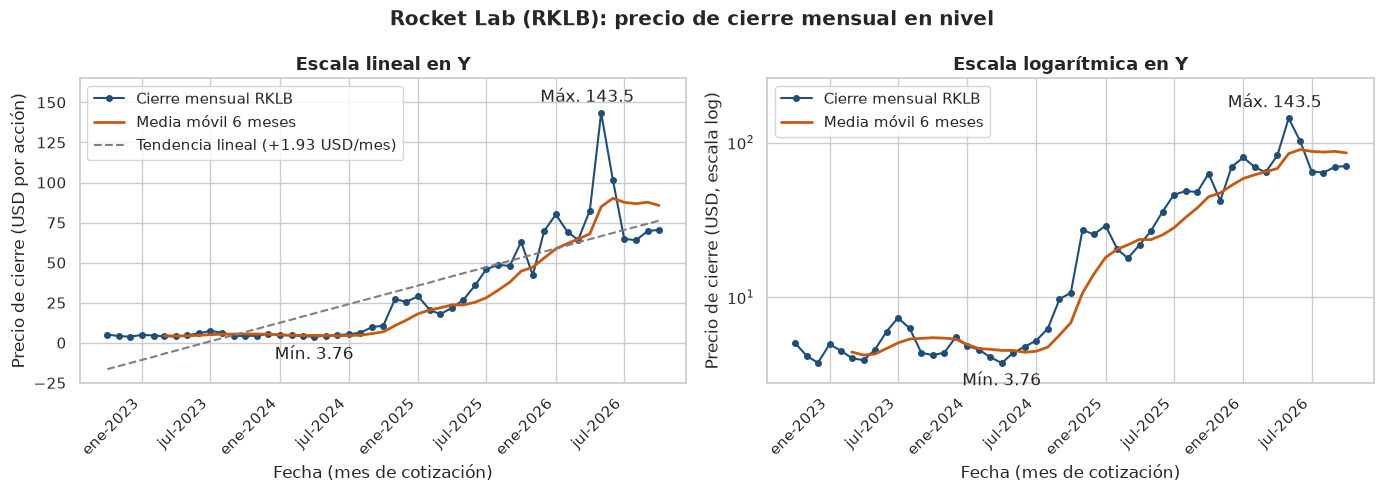

In [8]:
# Tendencia: OLS contra el índice de mes (nivel y logaritmo), media móvil 6 meses
t = np.arange(len(serie))
ols = sm.OLS(serie.values, sm.add_constant(t)).fit()
ols_log = sm.OLS(np.log(serie.values), sm.add_constant(t)).fit()
pend, p_pend, r2 = ols.params[1], ols.pvalues[1], ols.rsquared
g_mensual = (np.exp(ols_log.params[1]) - 1) * 100
mm6 = serie.rolling(6).mean()
print(f"Tendencia lineal en nivel: {pend:+.3f} USD/mes (p = {p_pend:.4f}; R² = {r2:.3f})")
print(f"Tendencia lineal en ln(Y): {ols_log.params[1]:+.4f} por mes ≈ {g_mensual:+.2f}% mensual compuesto (R² = {ols_log.rsquared:.3f})")

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
for ax, log in zip(axs, [False, True]):
    ax.plot(serie.index, serie.values, marker="o", ms=4, color=C_NIVEL, label="Cierre mensual RKLB")
    ax.plot(mm6.index, mm6.values, color=C_ALT, lw=2, label="Media móvil 6 meses")
    if not log: ax.plot(serie.index, ols.fittedvalues, color=C_REF, ls="--", label=f"Tendencia lineal ({pend:+.2f} USD/mes)")
    ax.annotate(f"Máx. {serie.max():.1f}", (imax, serie.max()), textcoords="offset points", xytext=(-10, 8), ha="center")
    ax.annotate(f"Mín. {serie.min():.2f}", (imin, serie.min()), textcoords="offset points", xytext=(0, -16), ha="center")
    ax.set(xlabel="Fecha (mes de cotización)", ylabel="Precio de cierre (USD, escala log)" if log else "Precio de cierre (USD por acción)")
    if log: ax.set_yscale("log"); ax.set_ylim(2.8, 260)
    else: ax.set_ylim(-25, 165)
    ax.set_title("Escala logarítmica en Y" if log else "Escala lineal en Y"); eje_fechas(ax); ax.legend(loc="upper left")
fig.suptitle("Rocket Lab (RKLB): precio de cierre mensual en nivel", fontweight="bold"); guarda(fig, "fig_03_nivel")
R.update(media=float(serie.mean()), std=float(serie.std()), mediana=float(serie.median()), minimo=float(serie.min()), maximo=float(serie.max()),
         f_min=str(imin.date()), f_max=str(imax.date()), primero=float(serie.iloc[0]), ultimo=float(serie.iloc[-1]),
         pend=float(pend), p_pend=float(p_pend), r2=float(r2), g_mensual=float(g_mensual), r2_log=float(ols_log.rsquared), cv=float(serie.std()/serie.mean()*100),
         caida_max=float((serie.iloc[-1]/serie.max()-1)*100), asim=float(serie.skew()))

In [9]:
# Patrón repetitivo: ¿hay un mes del año sistemáticamente alto o bajo? (exploratorio: solo 3-5 observaciones por mes calendario)
rl = (np.log(serie).diff() * 100)
tmp = pd.DataFrame({"r": rl}); tmp["mes"] = tmp.index.month
est = tmp.groupby("mes")["r"].agg(n="count", media="mean", mediana="median").round(2)
est.index = [MESES[m - 1] for m in est.index]; est.columns = ["n", "cambio log medio (%)", "cambio log mediano (%)"]
est.to_csv("tablas/t03_estacionalidad_mes.csv"); display(est)
print("Meses con cambio medio positivo:", int((est.iloc[:, 1] > 0).sum()), "de 12 | n por mes:", sorted(est["n"].unique().tolist()))
R["est_mes"] = est.reset_index().rename(columns={"index": "mes"}).to_dict("records")

,n,cambio log medio (%),cambio log mediano (%)
ene,4,10.36,13.47
feb,4,-16.30,-12.33
mar,4,-10.67,-10.86
abr,4,8.23,8.38
may,4,26.65,18.11
jun,4,7.71,18.20
jul,4,2.38,14.67
ago,4,1.62,2.04
sep,4,3.66,3.60
oct,4,8.62,5.31


Meses con cambio medio positivo: 10 de 12 | n por mes: [4]


### Respuestas

**¿Se observa tendencia?**  
Sí, una **tendencia creciente muy marcada pero no monótona**. El precio pasó de 5.09 USD (oct-2022) a 70.46 USD (oct-2026), un aumento de 1,284 %. La recta de tendencia suma 1.93 USD por mes (p < 0.001; R² = 0.715), y en logaritmos el crecimiento equivale a 8.2 % mensual compuesto (R² = 0.861), es decir, la trayectoria es más exponencial que lineal. De oct-2022 a mediados de 2024 el precio estuvo plano entre 3.76 y 7.37 USD; desde nov-2024 despegó, alcanzó el máximo de **143.48 USD en may-2026** y después cayó 50.9 % hasta el último dato.

**¿Hay algún patrón repetitivo?**  
No hay una estacionalidad clara. Lo que se repite son **ciclos de auge y corrección**: una racha de 7 alzas mensuales consecutivas entre may-2024 y nov-2024 (cambio logarítmico acumulado de 198.2 %), otra de 5 alzas entre abr-2025 y ago-2025 (100.0 %), seguidas de caídas. Por mes calendario, 10 de 12 meses tienen cambio promedio positivo (reflejo de la tendencia); solo febrero (−16.3 %) y marzo (−10.7 %) tienen media y mediana negativas, pero hay apenas 4 observaciones por mes y la desviación mensual es de 26.0 %, así que no se puede afirmar un patrón estacional.

**¿La variabilidad parece constante?**  
No. La desviación estándar del precio crece año con año: 0.67 USD (2022), 1.07 (2023), 8.29 (2024), 16.77 (2025) y 24.82 (2026). La primera mitad de la muestra tiene desviación de 1.35 USD y la segunda de 30.28 USD (**22.5 veces mayor**). La variabilidad aumenta junto con el nivel (heterocedasticidad), por lo que en el panel de escala logarítmica las oscilaciones se ven más parejas que en la escala lineal.

**¿Qué periodos llaman particularmente la atención?**  
(1) **nov-2024**: el precio pasó de 10.70 a 27.28 USD en un solo mes (+154.95 %), el mayor salto de la muestra y el inicio de un nuevo rango de precios (desde entonces nunca volvió por debajo de 17.88 USD). (2) **dic-2025 y may-2026**: alzas de +65.5 % y +73.9 %, esta última hasta el máximo de 143.48 USD. (3) **jun-2026 y jul-2026**: caídas de −29.2 % y −36.1 % (de 143.48 a 64.95 USD en dos meses). (4) **sep-2023**: caída de −30.6 % cuando el precio era de solo 4–6 USD. (5) El mínimo de 3.76 USD en abr-2024.

## 4. Primera diferencia  ΔYₜ = Yₜ − Yₜ₋₁

,Cierre (USD),ΔY (USD)
Fecha,,
2022-10,5.09,NaN
2022-11,4.19,-0.90
2022-12,3.77,-0.42
2023-01,4.97,1.20
2023-02,4.50,-0.47
2023-03,4.04,-0.46
2023-04,3.92,-0.12
2023-05,4.58,0.66
2023-06,6.00,1.42


Meses con ΔY>0: 26 | ΔY<0: 22 | ΔY=0: 0
Media: +1.362 USD | desv. est.: 14.143 USD | máx.: +60.97 (may-2026) | mín.: -41.83 (jun-2026)
Desv. est. de ΔY: 1ª mitad 1.10 USD | 2ª mitad 20.12 USD


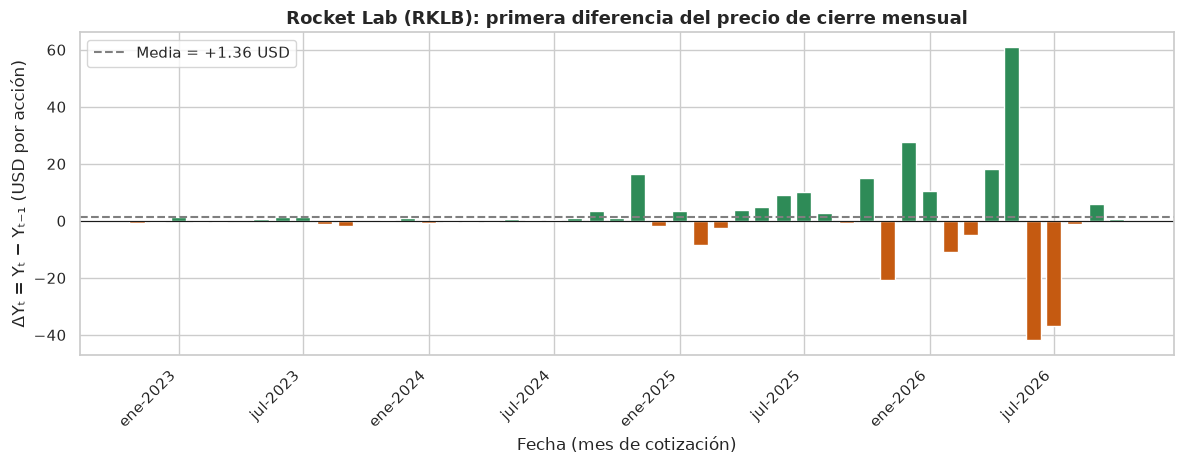

In [10]:
dif = serie.diff().rename("ΔY (USD)")
t4 = pd.concat([serie, dif], axis=1); t4.index = t4.index.strftime("%Y-%m")
t4.round(2).to_csv("tablas/t04_primera_diferencia.csv"); display(t4.round(2).head(12))
d = dif.dropna()
print(f"Meses con ΔY>0: {(d>0).sum()} | ΔY<0: {(d<0).sum()} | ΔY=0: {(d==0).sum()}")
print(f"Media: {d.mean():+.3f} USD | desv. est.: {d.std():.3f} USD | máx.: {d.max():+.2f} ({fmt_fecha(d.idxmax())}) | mín.: {d.min():+.2f} ({fmt_fecha(d.idxmin())})")
print(f"Desv. est. de ΔY: 1ª mitad {d.iloc[:len(d)//2].std():.2f} USD | 2ª mitad {d.iloc[len(d)//2:].std():.2f} USD")

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.bar(d.index, d.values, color=np.where(d.values >= 0, C_TEST, C_ALT), width=22)
ax.axhline(0, color="k", lw=0.8); ax.axhline(d.mean(), color=C_REF, ls="--", label=f"Media = {d.mean():+.2f} USD")
ax.set(title="Rocket Lab (RKLB): primera diferencia del precio de cierre mensual", xlabel="Fecha (mes de cotización)", ylabel="ΔYₜ = Yₜ − Yₜ₋₁ (USD por acción)")
eje_fechas(ax); ax.legend(); guarda(fig, "fig_04_primera_diferencia")
R.update(d_pos=int((d>0).sum()), d_neg=int((d<0).sum()), d_media=float(d.mean()), d_std=float(d.std()),
         d_max=float(d.max()), f_d_max=str(d.idxmax().date()), d_min=float(d.min()), f_d_min=str(d.idxmin().date()),
         d_std_h1=float(d.iloc[:len(d)//2].std()), d_std_h2=float(d.iloc[len(d)//2:].std()))

### Respuestas

**¿Qué significa una diferencia positiva y una negativa?**  
ΔY > 0 significa que la acción **cerró el mes más alta que el mes anterior** (26 de 48 meses; el mayor aumento fue +60.97 USD en may-2026). ΔY < 0 significa que cerró **más baja** (22 meses; la mayor caída fue -41.83 USD en jun-2026).

**¿En qué unidades se interpreta?**  
En **USD por acción por mes**, las mismas unidades que el nivel: ΔY = +60.97 significa que el precio subió 60.97 dólares respecto al mes previo.

**¿Qué cambia respecto del nivel?**  
La serie deja de describir «cuánto vale» y pasa a describir «cuánto cambió». **Desaparece la tendencia**: el nivel tiene media de 29.87 USD y autocorrelación de rezago 1 de 0.906, mientras que ΔY oscila alrededor de +1.36 USD con autocorrelación de rezago 1 de −0.060. Pero **no se corrige la variabilidad**: la desviación de ΔY es de 1.10 USD en la primera mitad y de 20.12 USD en la segunda, porque los saltos en dólares crecen con el precio.

## 5. Logaritmo natural  ln(Yₜ)

¿Todos los cierres son estrictamente positivos? True (mínimo = 3.76 USD)


,Cierre (USD),ln(Y)
Fecha,,
2022-10,5.09,1.6273
2022-11,4.19,1.4327
2022-12,3.77,1.3271
2023-01,4.97,1.6034
2023-02,4.50,1.5041
2023-03,4.04,1.3962
2023-04,3.92,1.3661
2023-05,4.58,1.5217
2023-06,6.00,1.7918


Rango en nivel: 3.76–143.48 USD (el máximo es 38.2 veces el mínimo)
Rango en logaritmo: 1.3244–4.9662 (amplitud 3.642 unidades log)
Correlación entre Y y ln(Y): 0.9214 (no es 1: el log comprime los valores altos)
Desv. est. del nivel: 1ª mitad 1.35 vs 2ª mitad 30.28 (razón 22.5x)
Desv. est. de ln(Y):  1ª mitad 0.227 vs 2ª mitad 0.617 (razón 2.7x)
ADF sobre ln(Y): estadístico = -0.466, p = 0.898  (orientativo)


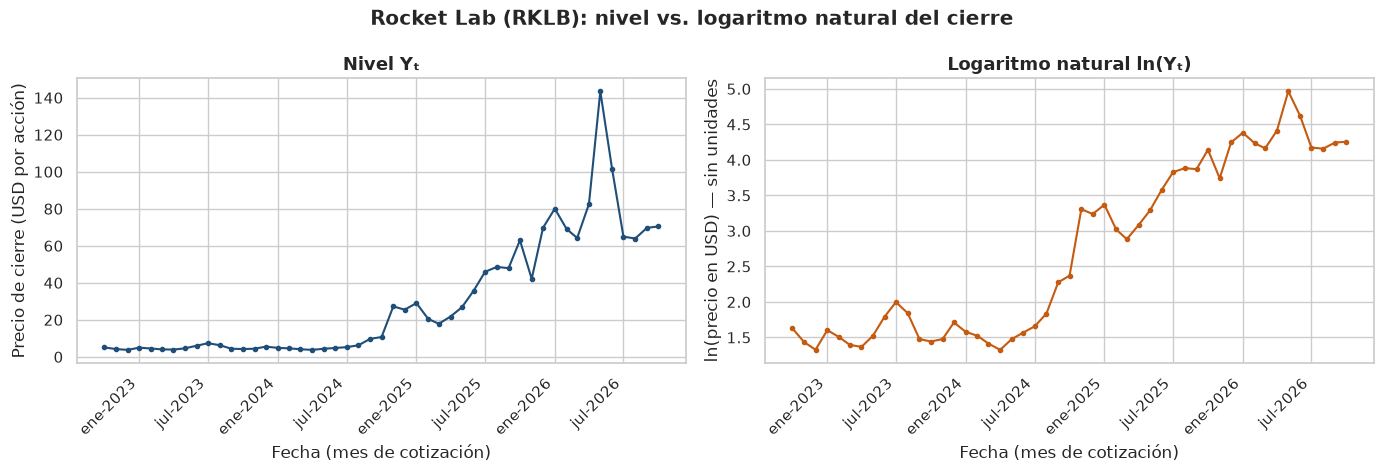

In [11]:
positiva = bool((serie > 0).all())
print("¿Todos los cierres son estrictamente positivos?", positiva, f"(mínimo = {serie.min():.2f} USD)")
lnY = np.log(serie).rename("ln(Y)")
t5 = pd.concat([serie, lnY], axis=1); t5.index = t5.index.strftime("%Y-%m")
t5.round(4).to_csv("tablas/t05_log_nivel.csv"); display(t5.round(4).head(10))
print(f"Rango en nivel: {serie.min():.2f}–{serie.max():.2f} USD (el máximo es {serie.max()/serie.min():.1f} veces el mínimo)")
print(f"Rango en logaritmo: {lnY.min():.4f}–{lnY.max():.4f} (amplitud {lnY.max()-lnY.min():.3f} unidades log)")
print(f"Correlación entre Y y ln(Y): {serie.corr(lnY):.4f} (no es 1: el log comprime los valores altos)")
# Dispersión relativa entre mitades: nivel vs log
h = len(serie) // 2
print(f"Desv. est. del nivel: 1ª mitad {serie.iloc[:h].std():.2f} vs 2ª mitad {serie.iloc[h:].std():.2f} (razón {serie.iloc[h:].std()/serie.iloc[:h].std():.1f}x)")
print(f"Desv. est. de ln(Y):  1ª mitad {lnY.iloc[:h].std():.3f} vs 2ª mitad {lnY.iloc[h:].std():.3f} (razón {lnY.iloc[h:].std()/lnY.iloc[:h].std():.1f}x)")
adf_ln = adfuller(lnY, maxlag=4, autolag="AIC")
print(f"ADF sobre ln(Y): estadístico = {adf_ln[0]:.3f}, p = {adf_ln[1]:.3f}  (orientativo)")

fig, axs = plt.subplots(1, 2, figsize=(14, 4.8))
axs[0].plot(serie.index, serie.values, marker="o", ms=3, color=C_NIVEL); axs[0].set(title="Nivel Yₜ", xlabel="Fecha (mes de cotización)", ylabel="Precio de cierre (USD por acción)")
axs[1].plot(lnY.index, lnY.values, marker="o", ms=3, color=C_ALT); axs[1].set(title="Logaritmo natural ln(Yₜ)", xlabel="Fecha (mes de cotización)", ylabel="ln(precio en USD) — sin unidades")
for a in axs: eje_fechas(a)
fig.suptitle("Rocket Lab (RKLB): nivel vs. logaritmo natural del cierre", fontweight="bold"); guarda(fig, "fig_05_log_nivel")
R.update(positiva=positiva, ln_min=float(lnY.min()), ln_max=float(lnY.max()), adf_ln_p=float(adf_ln[1]), adf_ln_stat=float(adf_ln[0]),
         corr_y_ln=float(serie.corr(lnY)), razon_max_min=float(serie.max()/serie.min()),
         std_niv_h1=float(serie.iloc[:h].std()), std_niv_h2=float(serie.iloc[h:].std()), std_ln_h1=float(lnY.iloc[:h].std()), std_ln_h2=float(lnY.iloc[h:].std()))

### Respuestas

**¿Es válido aplicar logaritmo a su serie?**  
Sí. El logaritmo exige valores estrictamente positivos y el cierre mínimo de RKLB es de 3.76 USD (los 49 cierres son > 0). Un precio accionario además no puede ser cero o negativo.

**¿Qué efecto tiene sobre la escala?**  
Comprime los valores altos y expande los bajos: el máximo es 38.2 veces el mínimo en nivel, pero en ln la amplitud es de 3.64 unidades (de 1.32 a 4.97). El crecimiento casi exponencial se vuelve más lineal (R² de la tendencia: 0.715 en nivel vs 0.861 en ln) y la desproporción de variabilidad entre mitades baja de 22.5 veces en nivel a 2.7 veces en ln. Además, las diferencias en ln son variaciones relativas.

**¿El logaritmo garantiza estacionariedad? Expliquen.**  
**No.** El logaritmo solo es una transformación de escala monótona: no elimina la tendencia ni el nivel cambiante. ln(Y) sube de 1.32 a 4.97 y mantiene una autocorrelación de rezago 1 de 0.977 (incluso mayor que la del nivel, 0.906); la prueba ADF, usada solo como apoyo orientativo, da p = 0.898, sin evidencia contra una raíz unitaria. Además, la variabilidad de ln(Y) sigue siendo 2.7 veces mayor en la segunda mitad. Para quitar la tendencia hay que diferenciar (por ejemplo, tomar el cambio logarítmico).

## 6. Cambio porcentual simple  [(Yₜ − Yₜ₋₁)/Yₜ₋₁] × 100

,Cierre (USD),ΔY (USD),Cambio simple (%)
Fecha,,,
2022-10,5.09,NaN,NaN
2022-11,4.19,-0.90,-17.682
2022-12,3.77,-0.42,-10.024
2023-01,4.97,1.20,31.830
2023-02,4.50,-0.47,-9.457
2023-03,4.04,-0.46,-10.222
2023-04,3.92,-0.12,-2.970
2023-05,4.58,0.66,16.837
2023-06,6.00,1.42,31.004


NaN en la primera observación: True | NaN totales: 1
Positivos: 26 | negativos: 22 | media +9.41% | mediana +4.69% | desv. est. 32.27% | máx +154.95% (nov-2024) | mín -36.10% (jul-2026)
Ej. mayor alza: nov-2024: 10.70 -> 27.28 USD (ΔY = +16.58 USD) = +154.95%
Ej. mayor caída: jul-2026: 101.65 -> 64.95 USD (ΔY = -36.70 USD) = -36.10%
Mayor |ΔY|: may-2026 (+60.97 USD) = +73.89%
Mayor |ΔY| de 2023: sep-2023 = -1.93 USD, pero -30.59%


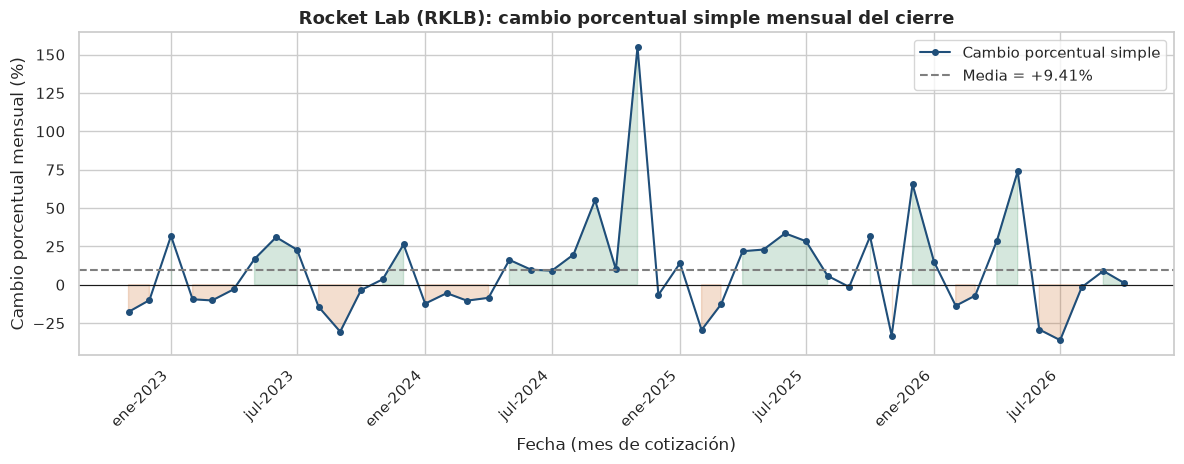

In [12]:
pct = (serie.pct_change() * 100).rename("Cambio simple (%)")
t6 = pd.concat([serie, dif, pct], axis=1); t6.index = t6.index.strftime("%Y-%m")
t6.round(3).to_csv("tablas/t06_cambio_simple.csv"); display(t6.round(3).head(10))
print("NaN en la primera observación:", bool(np.isnan(pct.iloc[0])), "| NaN totales:", int(pct.isna().sum()))
p = pct.dropna()
print(f"Positivos: {(p>0).sum()} | negativos: {(p<0).sum()} | media {p.mean():+.2f}% | mediana {p.median():+.2f}% | desv. est. {p.std():.2f}% | máx {p.max():+.2f}% ({fmt_fecha(p.idxmax())}) | mín {p.min():+.2f}% ({fmt_fecha(p.idxmin())})")
# Una misma ΔY en USD implica cambios relativos muy distintos según el nivel de partida
i = p.idxmax(); j = p.idxmin()
print(f"Ej. mayor alza: {fmt_fecha(i)}: {serie.shift(1)[i]:.2f} -> {serie[i]:.2f} USD (ΔY = {dif[i]:+.2f} USD) = {p[i]:+.2f}%")
print(f"Ej. mayor caída: {fmt_fecha(j)}: {serie.shift(1)[j]:.2f} -> {serie[j]:.2f} USD (ΔY = {dif[j]:+.2f} USD) = {p[j]:+.2f}%")
k = d.abs().idxmax(); print(f"Mayor |ΔY|: {fmt_fecha(k)} ({dif[k]:+.2f} USD) = {pct[k]:+.2f}%")
# Comparación: ΔY de magnitud parecida en USD, en 2023 vs 2026
a = dif.abs().loc["2023-01-01":"2023-12-01"].max(); ia = dif.abs().loc["2023-01-01":"2023-12-01"].idxmax()
print(f"Mayor |ΔY| de 2023: {fmt_fecha(ia)} = {dif[ia]:+.2f} USD, pero {pct[ia]:+.2f}%")

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(p.index, p.values, marker="o", ms=4, color=C_NIVEL, label="Cambio porcentual simple")
ax.axhline(0, color="k", lw=0.8); ax.axhline(p.mean(), color=C_REF, ls="--", label=f"Media = {p.mean():+.2f}%")
ax.fill_between(p.index, p.values, 0, where=p.values >= 0, color=C_TEST, alpha=0.2); ax.fill_between(p.index, p.values, 0, where=p.values < 0, color=C_ALT, alpha=0.2)
ax.set(title="Rocket Lab (RKLB): cambio porcentual simple mensual del cierre", xlabel="Fecha (mes de cotización)", ylabel="Cambio porcentual mensual (%)")
eje_fechas(ax); ax.legend(); guarda(fig, "fig_06_cambio_simple")
R.update(p_pos=int((p>0).sum()), p_neg=int((p<0).sum()), p_media=float(p.mean()), p_mediana=float(p.median()), p_std=float(p.std()),
         p_max=float(p.max()), f_p_max=str(i.date()), p_min=float(p.min()), f_p_min=str(j.date()),
         ej_prev=float(serie.shift(1)[i]), ej_act=float(serie[i]), ej_dif=float(dif[i]),
         ej2_prev=float(serie.shift(1)[j]), ej2_act=float(serie[j]), ej2_dif=float(dif[j]),
         k_dif=float(dif[k]), k_pct=float(pct[k]), f_k=str(k.date()), a_dif=float(dif[ia]), a_pct=float(pct[ia]), f_a=str(ia.date()))

### Respuestas

**¿Cómo interpretan valores positivos y negativos?**  
Un valor positivo es un **aumento porcentual** del precio respecto al mes anterior; uno negativo, una **disminución porcentual**. Hubo 26 meses positivos y 22 negativos; el cambio promedio es de +9.41 % (mediana +4.69 %) con desviación de 32.27 %. Por ejemplo, +154.95 % en nov-2024 significa que el precio de 10.70 USD se multiplicó por 2.55 hasta 27.28 USD, y -36.10 % en jul-2026 significa que bajó de 101.65 a 64.95 USD.

**¿Por qué aparece NaN en la primera observación?**  
Porque la fórmula necesita Y(t−1) y para oct-2022, el primer mes de la muestra, no existe un mes previo en la base; el cálculo es indefinido. Se tiene 1 NaN, por lo que quedan 48 cambios porcentuales. No se imputa.

**¿Qué diferencia existe respecto de la primera diferencia?**  
La primera diferencia es **absoluta** (USD) y depende del nivel de precio; el cambio simple es **relativo** (% del precio previo) y no tiene unidades. Ejemplos de RKLB: en sep-2023 el precio cayó solo 1.93 USD, pero eso fue -30.59 %; en may-2026 la mayor variación en dólares (+60.97 USD) fue +73.89 %; en cambio, el mayor cambio relativo (+154.95 %, nov-2024) solo representó +16.58 USD. Con ΔY, los meses de 2026 parecen enormes y los de 2023 insignificantes; con el cambio porcentual son comparables.

## 7. Cambio logarítmico  [ln(Yₜ) − ln(Yₜ₋₁)] × 100

Ambas fórmulas coinciden: True


,Cierre (USD),Cambio simple (%),Cambio log (%)
Fecha,,,
2022-10,5.09,NaN,NaN
2022-11,4.19,-17.682,-19.458
2022-12,3.77,-10.024,-10.563
2023-01,4.97,31.830,27.634
2023-02,4.50,-9.457,-9.934
2023-03,4.04,-10.222,-10.783
2023-04,3.92,-2.970,-3.015
2023-05,4.58,16.837,15.561
2023-06,6.00,31.004,27.006


Media +5.47% | mediana +4.58% | desv. est. 25.98% | máx +93.59% (nov-2024) | mín -44.79% (jul-2026)
Correlación cambio simple vs. logarítmico: 0.9718
Diferencia (simple − log): media +3.94 pp | mediana +1.09 pp | máxima en valor absoluto 61.36 pp en nov-2024
Para |cambio| < 10% (16 meses): diferencia máxima 0.48 pp | para |cambio| ≥ 10% (32 meses): 61.36 pp
Suma de cambios log = 262.78%  vs  ln(Y_final/Y_inicial)·100 = 262.78%  (aditividad)
Cambio simple acumulado = 1284.3%  (≠ suma de cambios simples = 451.8%)
Simetría: un +100% simple seguido de -50% simple deja el precio igual (log: 69.3% y -69.3%)


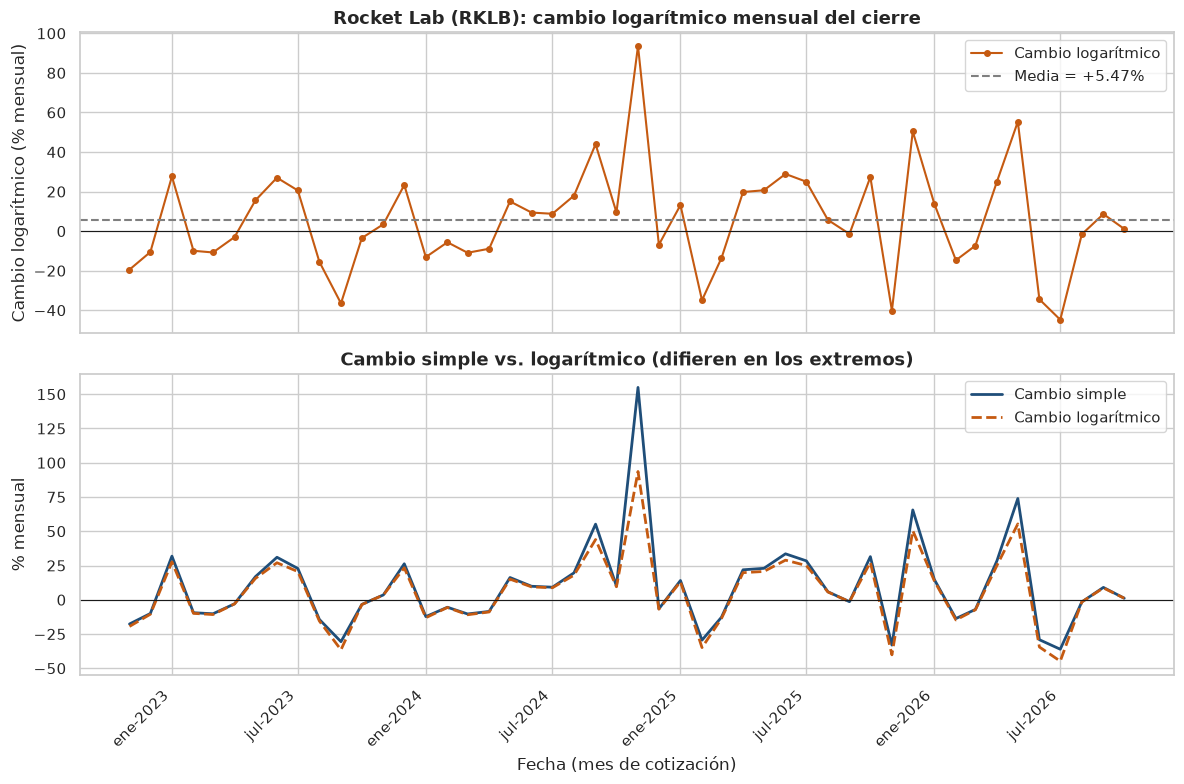

In [13]:
lr = (lnY.diff() * 100).rename("Cambio log (%)")
lr_alt = (np.log(serie / serie.shift(1)) * 100)
print("Ambas fórmulas coinciden:", bool(np.allclose(lr.dropna(), lr_alt.dropna())))
t7 = pd.concat([serie, pct, lr], axis=1); t7.index = t7.index.strftime("%Y-%m")
t7.round(3).to_csv("tablas/t07_cambio_log.csv"); display(t7.round(3).head(10))
r = lr.dropna(); brecha = (pct - lr).dropna()
print(f"Media {r.mean():+.2f}% | mediana {r.median():+.2f}% | desv. est. {r.std():.2f}% | máx {r.max():+.2f}% ({fmt_fecha(r.idxmax())}) | mín {r.min():+.2f}% ({fmt_fecha(r.idxmin())})")
print(f"Correlación cambio simple vs. logarítmico: {pct.corr(lr):.4f}")
print(f"Diferencia (simple − log): media {brecha.mean():+.2f} pp | mediana {brecha.median():+.2f} pp | máxima en valor absoluto {brecha.abs().max():.2f} pp en {fmt_fecha(brecha.abs().idxmax())}")
peq = p.abs() < 10
print(f"Para |cambio| < 10% ({int(peq.sum())} meses): diferencia máxima {brecha[peq].abs().max():.2f} pp | para |cambio| ≥ 10% ({int((~peq).sum())} meses): {brecha[~peq].abs().max():.2f} pp")
print(f"Suma de cambios log = {r.sum():.2f}%  vs  ln(Y_final/Y_inicial)·100 = {np.log(serie.iloc[-1]/serie.iloc[0])*100:.2f}%  (aditividad)")
print(f"Cambio simple acumulado = {(serie.iloc[-1]/serie.iloc[0]-1)*100:.1f}%  (≠ suma de cambios simples = {p.sum():.1f}%)")
# Simetría: +50% y -50% simples no se compensan; en log sí lo hacen con +x y -x
print(f"Simetría: un +100% simple seguido de -50% simple deja el precio igual (log: {np.log(2)*100:.1f}% y {np.log(0.5)*100:.1f}%)")

fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axs[0].plot(r.index, r.values, marker="o", ms=4, color=C_ALT, label="Cambio logarítmico"); axs[0].axhline(0, color="k", lw=0.8)
axs[0].axhline(r.mean(), color=C_REF, ls="--", label=f"Media = {r.mean():+.2f}%")
axs[0].set(title="Rocket Lab (RKLB): cambio logarítmico mensual del cierre", ylabel="Cambio logarítmico (% mensual)"); axs[0].legend()
axs[1].plot(p.index, p.values, color=C_NIVEL, label="Cambio simple", lw=2); axs[1].plot(r.index, r.values, color=C_ALT, ls="--", label="Cambio logarítmico", lw=2); axs[1].axhline(0, color="k", lw=0.8)
axs[1].set(title="Cambio simple vs. logarítmico (difieren en los extremos)", xlabel="Fecha (mes de cotización)", ylabel="% mensual"); axs[1].legend()
eje_fechas(axs[1]); guarda(fig, "fig_07_cambio_log")
R.update(r_media=float(r.mean()), r_mediana=float(r.median()), r_std=float(r.std()), r_max=float(r.max()), f_r_max=str(r.idxmax().date()), r_min=float(r.min()), f_r_min=str(r.idxmin().date()),
         r_pos=int((r>0).sum()), r_neg=int((r<0).sum()),
         corr_simple_log=float(pct.corr(lr)), brecha_max=float(brecha.abs().max()), f_brecha_max=str(brecha.abs().idxmax().date()), brecha_media=float(brecha.mean()),
         n_peq=int(peq.sum()), brecha_peq=float(brecha[peq].abs().max()), n_gr=int((~peq).sum()), brecha_gr=float(brecha[~peq].abs().max()),
         suma_log=float(r.sum()), ln_total=float(np.log(serie.iloc[-1]/serie.iloc[0])*100), simple_acum=float((serie.iloc[-1]/serie.iloc[0]-1)*100), suma_simples=float(p.sum()))

### Respuestas

**¿Cómo se interpreta el signo?**  
Positivo: el logaritmo del precio subió, o sea, el precio **aumentó** respecto al mes anterior (26 meses); negativo: el precio **disminuyó** (22 meses). La magnitud, multiplicada por 100, es una variación porcentual continua: +93.59 % en nov-2024 equivale a multiplicar el precio por e^0.936 = 2.55, y -44.79 % en jul-2026 a multiplicarlo por e^−0.448 = 0.64.

**¿Qué tan parecido es al cambio porcentual simple?**  
Muy parecido cuando el cambio es pequeño y distinto cuando es grande. En toda la muestra la correlación entre ambos es de 0.9718. En los 16 meses con |cambio| < 10 %, la diferencia máxima es de apenas 0.48 puntos porcentuales; en los 32 meses con |cambio| ≥ 10 % llega a 61.36 puntos (en nov-2024: +154.95 % simple vs +93.59 % logarítmico). Como RKLB se mueve en promedio 32.3 % por mes, la diferencia es relevante: el cambio promedio es de 9.41 % en simple y de 5.47 % en logarítmico.

**¿Qué ventaja presenta para estudiar cambios a través del tiempo?**  
(1) **Es aditivo en el tiempo**: la suma de los 48 cambios logarítmicos (262.78 %) es exactamente ln(Y final / Y inicial)·100; con cambios simples no funciona (su suma es 451.8 % y el cambio acumulado real es 1,284.3 %). (2) Es **simétrico**: +100 % y −50 % simples dejan el precio igual, mientras que en logaritmos son +69.3 % y −69.3 %. (3) No está acotado por −100 % y su distribución es menos asimétrica (media 5.47 % y mediana 4.58 %, frente a 9.41 % y 4.69 % en simple).

## 8. Comparación de transformaciones

,Nivel (USD),1ª diferencia (USD),ln(Y),Cambio simple (%),Cambio log (%)
Fecha,,,,,
2022-10,5.09,NaN,1.627,NaN,NaN
2022-11,4.19,-0.90,1.433,-17.682,-19.458
2022-12,3.77,-0.42,1.327,-10.024,-10.563
2023-01,4.97,1.20,1.603,31.830,27.634
2023-02,4.50,-0.47,1.504,-9.457,-9.934
2023-03,4.04,-0.46,1.396,-10.222,-10.783
2023-04,3.92,-0.12,1.366,-2.970,-3.015
2023-05,4.58,0.66,1.522,16.837,15.561
2023-06,6.00,1.42,1.792,31.004,27.006


,n,media,desv. est.,mín,máx,autocorr. lag 1,autocorr. lag 6,p-valor ADF
Nivel (USD),49.0,29.868,32.608,3.760,143.480,0.906,0.821,0.840
1ª diferencia (USD),48.0,1.362,14.143,-41.830,60.970,-0.060,-0.473,0.000
ln(Y),49.0,2.727,1.217,1.324,4.966,0.977,0.885,0.898
Cambio simple (%),48.0,9.413,32.266,-36.104,154.953,-0.012,-0.006,0.000
Cambio log (%),48.0,5.475,25.984,-44.792,93.591,0.034,-0.041,0.000


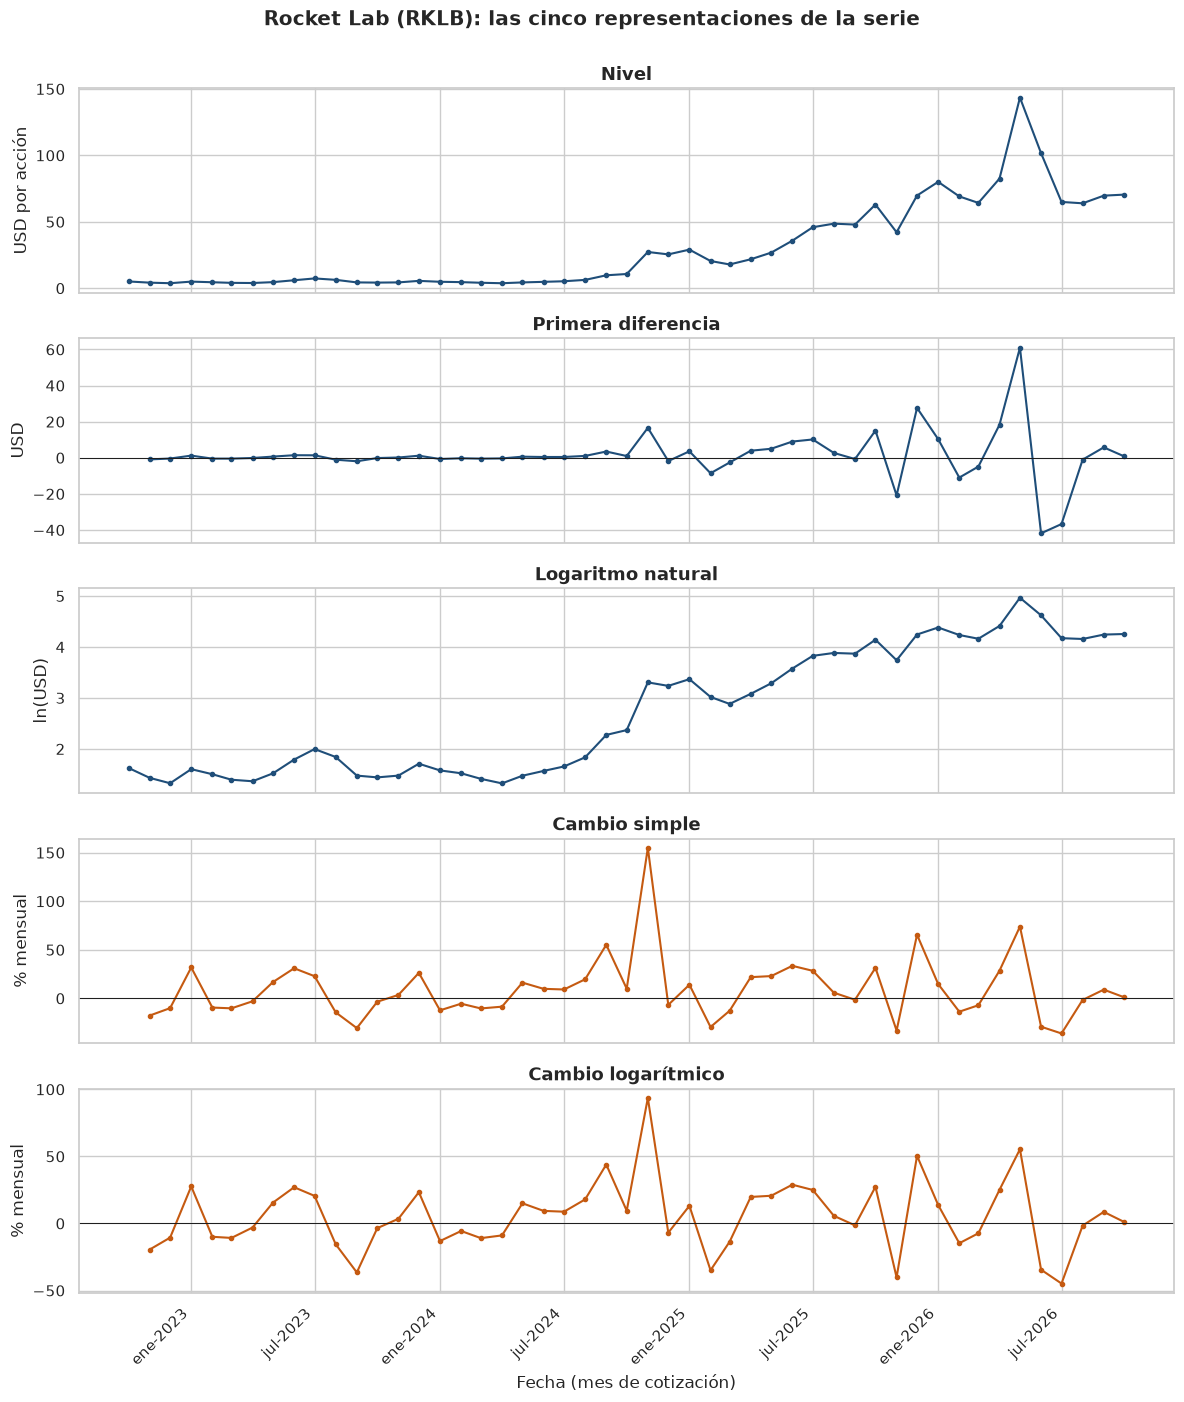

In [14]:
comp = pd.DataFrame({"Nivel (USD)": serie, "1ª diferencia (USD)": dif, "ln(Y)": lnY, "Cambio simple (%)": pct, "Cambio log (%)": lr})
comp_f = comp.copy(); comp_f.index = comp_f.index.strftime("%Y-%m")
comp_f.round(4).to_csv("tablas/t08_comparacion_completa.csv"); display(comp_f.round(3).head(15))

def resumen(x):
    x = x.dropna()
    return pd.Series({"n": len(x), "media": x.mean(), "desv. est.": x.std(), "mín": x.min(), "máx": x.max(), "autocorr. lag 1": x.autocorr(1),
                      "autocorr. lag 6": x.autocorr(6), "p-valor ADF": adfuller(x, maxlag=4, autolag="AIC")[1]})
res = comp.apply(resumen).T.round(3); res.to_csv("tablas/t08_resumen_transformaciones.csv"); display(res)

fig, axs = plt.subplots(5, 1, figsize=(12, 14), sharex=True)
etiquetas = [("Nivel", "USD por acción"), ("Primera diferencia", "USD"), ("Logaritmo natural", "ln(USD)"), ("Cambio simple", "% mensual"), ("Cambio logarítmico", "% mensual")]
for ax, col, (tt, yl) in zip(axs, comp.columns, etiquetas):
    ax.plot(comp.index, comp[col], marker="o", ms=3, color=C_NIVEL if col in comp.columns[:3] else C_ALT); ax.set(title=tt, ylabel=yl)
    if tt not in ("Nivel", "Logaritmo natural"): ax.axhline(0, color="k", lw=0.7)
axs[-1].set_xlabel("Fecha (mes de cotización)"); eje_fechas(axs[-1])
fig.suptitle("Rocket Lab (RKLB): las cinco representaciones de la serie", fontweight="bold", y=1.0); guarda(fig, "fig_08_comparacion")
R["res_transf"] = res.reset_index().rename(columns={"index": "Transformación"}).to_dict("records")

### Respuestas

**¿Qué información conserva cada transformación?**  
**Nivel**: el valor en USD, incluida la tendencia (autocorr. rezago 1 = 0.906). **1ª diferencia**: el cambio absoluto en USD; sin tendencia pero dependiente de la escala. **ln(Y)**: la forma completa del nivel en escala relativa (autocorr. rezago 1 = 0.977). **Cambio simple**: la variación relativa (%) mes a mes, asimétrica (de -36.1 % a 155.0 %). **Cambio logarítmico**: la variación relativa continua (%), aditiva y más simétrica (de -44.8 % a 93.6 %). Las tres últimas transformaciones pierden el nivel absoluto del precio.

**¿Cuál facilita los cambios relativos?**  
El **cambio porcentual simple** y el **cambio logarítmico**, porque expresan cada variación como proporción del precio previo. El logarítmico es el más conveniente para el análisis temporal (aditividad y simetría); el simple es el más directo para comunicar un rendimiento mensual.

**¿Cuál parece reducir más la tendencia o persistencia visual?**  
El **cambio logarítmico** y el **cambio simple**: sus gráficas oscilan alrededor de cero sin tendencia y sus autocorrelaciones de rezago 1 son 0.034 y -0.012 (frente a 0.906 del nivel y 0.977 de ln). La primera diferencia también elimina la tendencia, pero sus oscilaciones crecen con el tiempo (desv. de 1.10 USD a 20.12 USD). ln(Y) conserva casi toda la persistencia.

## 9. División Train/Test (cronológica, 80 % / 20 %)

Conjunto,Observaciones,% de la muestra,Primer mes,Último mes,Precio medio (USD),Precio mín–máx (USD),Desv. est. cambio log (%)
Train,39,79.590000,oct-2022,dic-2025,16.760000,3.76–69.76,25.440000
Test,10,20.410000,ene-2026,oct-2026,81.000000,63.92–143.48,28.720000
Total,49,100.000000,oct-2022,oct-2026,29.870000,3.76–143.48,25.980000


Todas las fechas de Train son anteriores a las de Test: True
Test: el mínimo (63.92) NO supera al máximo de Train (69.76) -> traslape de rangos: sí


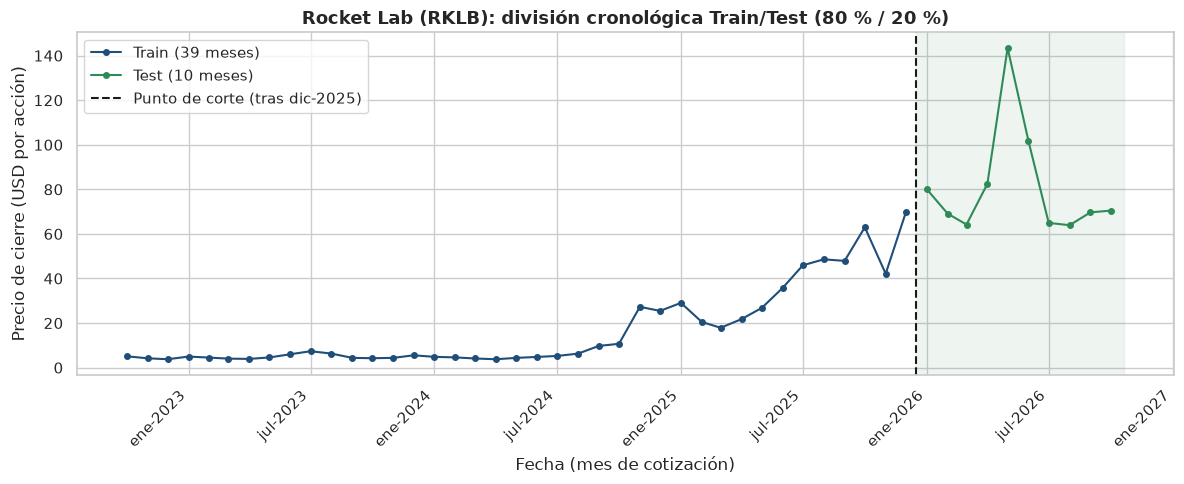

In [15]:
corte = int(len(serie) * 0.80)
train, test = serie.iloc[:corte], serie.iloc[corte:]
r_tr, r_te = lr.dropna().loc[:train.index[-1]], lr.loc[test.index[0]:]
split = pd.DataFrame({"Conjunto": ["Train", "Test", "Total"], "Observaciones": [len(train), len(test), len(serie)],
                      "% de la muestra": [len(train)/len(serie)*100, len(test)/len(serie)*100, 100.0],
                      "Primer mes": [fmt_fecha(train.index[0]), fmt_fecha(test.index[0]), fmt_fecha(serie.index[0])],
                      "Último mes": [fmt_fecha(train.index[-1]), fmt_fecha(test.index[-1]), fmt_fecha(serie.index[-1])],
                      "Precio medio (USD)": [train.mean(), test.mean(), serie.mean()],
                      "Precio mín–máx (USD)": [f"{train.min():.2f}–{train.max():.2f}", f"{test.min():.2f}–{test.max():.2f}", f"{serie.min():.2f}–{serie.max():.2f}"],
                      "Desv. est. cambio log (%)": [r_tr.std(), r_te.std(), lr.std()]}).round(2)
split.to_csv("tablas/t09_train_test.csv", index=False); display(split.style.hide(axis="index"))
print("Todas las fechas de Train son anteriores a las de Test:", train.index.max() < test.index.min())
print(f"Test: el mínimo ({test.min():.2f}) {'supera' if test.min() > train.max() else 'NO supera'} al máximo de Train ({train.max():.2f}) -> traslape de rangos: {'no' if test.min() > train.max() else 'sí'}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train.index, train.values, marker="o", ms=4, color=C_NIVEL, label=f"Train ({len(train)} meses)")
ax.plot(test.index, test.values, marker="o", ms=4, color=C_TEST, label=f"Test ({len(test)} meses)")
lim = train.index[-1] + (test.index[0] - train.index[-1]) / 2
ax.axvline(lim, color="k", ls="--", label=f"Punto de corte (tras {fmt_fecha(train.index[-1])})")
ax.axvspan(lim, test.index[-1] + pd.Timedelta(days=20), color=C_TEST, alpha=0.08)
ax.set(title="Rocket Lab (RKLB): división cronológica Train/Test (80 % / 20 %)", xlabel="Fecha (mes de cotización)", ylabel="Precio de cierre (USD por acción)")
eje_fechas(ax); ax.legend(loc="upper left"); guarda(fig, "fig_09_train_test")
R.update(n_train=len(train), n_test=len(test), tr_ini=str(train.index[0].date()), tr_fin=str(train.index[-1].date()), te_ini=str(test.index[0].date()), te_fin=str(test.index[-1].date()),
         media_train=float(train.mean()), media_test=float(test.mean()), max_train=float(train.max()), min_test=float(test.min()), max_test=float(test.max()), min_train=float(train.min()),
         std_r_train=float(r_tr.std()), std_r_test=float(r_te.std()), traslape=bool(test.min() <= train.max()))

### Respuestas

**¿Cuántas observaciones quedaron en cada conjunto?**  
**Train: 39 observaciones (79.6 %)** y **Test: 10 observaciones (20.4 %)**, de un total de 49 (corte = int(49 × 0.80) = 39).

**¿Qué fechas comprende cada uno?**  
Train: de **oct-2022 a dic-2025**. Test: de **ene-2026 a oct-2026** (incluye el mes parcial oct-2026). Todo Train es anterior a Test.

**¿Por qué no se utiliza una división aleatoria?**  
Porque en una serie de tiempo el orden contiene la información. Una división aleatoria (1) **filtraría información del futuro** al entrenamiento: se estimaría con meses de 2026 para «pronosticar» meses de 2025; (2) **rompería la dependencia temporal** que los rezagos y el ACF necesitan (la autocorrelación de rezago 1 es de 0.885); y (3) no imita el uso real, que es predecir un futuro todavía no observado. En RKLB el efecto sería grave: el precio medio es de 16.76 USD en Train y de 81.00 USD en Test, y el máximo de Test (143.48 USD) es 2.1 veces el de Train (69.76 USD); mezclar ambos regímenes subestimaría artificialmente el error de pronóstico.

**¿Para qué servirá Test posteriormente?**  
Para evaluar **fuera de muestra** los pronósticos de los modelos estimados únicamente con Train (comparar lo pronosticado contra lo observado de ene-2026 a oct-2026), comparar modelos y detectar sobreajuste. No debe usarse para elegir transformaciones ni parámetros. Como solo tiene 10 meses y el último es parcial, la evaluación tendrá poca potencia; y en nivel el Test queda casi totalmente fuera del rango visto en Train (mínimo de Test 63.92 USD vs máximo de Train 69.76 USD), mientras que en cambios logarítmicos las desviaciones son comparables (25.4 % en Train y 28.7 % en Test).

## 10. Rezagos y autocorrelación

In [16]:
lags = pd.DataFrame({"Mes": serie.index.strftime("%Y-%m"), "Y_t": serie.values, "Lag 1 (Y_t-1)": serie.shift(1).values,
                     "Lag 2 (Y_t-2)": serie.shift(2).values, "Lag 3 (Y_t-3)": serie.shift(3).values}).set_index("Mes")
lags.round(3).to_csv("tablas/t10_rezagos.csv"); display(lags.head(8).round(3))
print("NaN por columna:", lags.isna().sum().to_dict())

filas = []
acf_n = acf(serie, nlags=3, fft=False)
for k in (1, 2, 3):
    par = pd.concat([serie, serie.shift(k)], axis=1).dropna()
    filas.append({"Rezago (meses)": k, "Pares usados": len(par), "Correlación Y_t vs Y_t-k (Pearson)": par.iloc[:, 0].corr(par.iloc[:, 1]), "ACF muestral (statsmodels)": acf_n[k]})
tabla_ac = pd.DataFrame(filas).round(4); tabla_ac.to_csv("tablas/t10_autocorrelaciones_nivel.csv", index=False); display(tabla_ac.style.hide(axis="index"))

acf_r3 = acf(r, nlags=3, fft=False)
tabla_ac_r = pd.DataFrame([{"Rezago (meses)": k, "Correlación (Pearson)": r.autocorr(k), "ACF muestral (statsmodels)": acf_r3[k]} for k in (1, 2, 3)]).round(4)
tabla_ac_r.to_csv("tablas/t10_autocorrelaciones_retorno.csv", index=False); print("Cambio logarítmico:"); display(tabla_ac_r.style.hide(axis="index"))
R.update(ac_nivel=tabla_ac.to_dict("records"), ac_ret=tabla_ac_r.to_dict("records"))

,Y_t,Lag 1 (Y_t-1),Lag 2 (Y_t-2),Lag 3 (Y_t-3)
Mes,,,,
2022-10,5.09,NaN,NaN,NaN
2022-11,4.19,5.09,NaN,NaN
2022-12,3.77,4.19,5.09,NaN
2023-01,4.97,3.77,4.19,5.09
2023-02,4.50,4.97,3.77,4.19
2023-03,4.04,4.50,4.97,3.77
2023-04,3.92,4.04,4.50,4.97
2023-05,4.58,3.92,4.04,4.50


NaN por columna: {'Y_t': 0, 'Lag 1 (Y_t-1)': 1, 'Lag 2 (Y_t-2)': 2, 'Lag 3 (Y_t-3)': 3}


Rezago (meses),Pares usados,Correlación Y_t vs Y_t-k (Pearson),ACF muestral (statsmodels)
1,48,0.905800,0.884900
2,47,0.818800,0.779200
3,46,0.805700,0.748400


Cambio logarítmico:


Rezago (meses),Correlación (Pearson),ACF muestral (statsmodels)
1,0.034000,0.033700
2,-0.051600,-0.050800
3,-0.204800,-0.200000


### Respuestas

**¿Qué representa cada rezago según la frecuencia de la serie?**  
Como la serie es mensual, **Lag 1** es el precio de cierre del mes anterior, **Lag 2** el de hace dos meses y **Lag 3** el de hace tres meses (por ejemplo, para jun-2026 los rezagos son may-2026, abr-2026 y mar-2026).

**¿Por qué aparecen NaN?**  
Porque para los primeros meses no existe el pasado requerido: el primer mes (oct-2022) no tiene Lag 1; los dos primeros no tienen Lag 2 y los tres primeros no tienen Lag 3. Resultan 1, 2 y 3 NaN, y por eso las correlaciones se calculan con 48, 47 y 46 pares completos.

**¿Qué rezago presenta mayor autocorrelación?**  
En nivel, el **rezago 1**: 0.906 (Pearson; ACF muestral 0.885), seguido del rezago 2 (0.819) y el rezago 3 (0.806). En el cambio logarítmico las tres son pequeñas y la de mayor magnitud es el rezago 3 (-0.205).

**¿Cómo interpretan signo y magnitud?**  
Son **coeficientes de correlación** (adimensionales, entre −1 y 1), no porcentajes de cambio ni porcentaje explicado: 0.906 **no** significa que el precio suba 90.6 % ni que el mes anterior «explique» 90.6 % del actual. El signo positivo indica que un mes con precio alto suele ir seguido de otro con precio alto (y viceversa); la magnitud grande y decreciente (0.906, 0.819, 0.806) indica **fuerte persistencia del nivel**, consecuencia de la tendencia. En el cambio logarítmico (0.034, -0.052, -0.205) las magnitudes son cercanas a cero: el cambio de un mes casi no se relaciona linealmente con los de los tres meses previos. La pequeña diferencia entre Pearson y ACF se debe a que la ACF usa la media y la varianza de toda la muestra.

## 11. Correlograma ACF en nivel

Rezago,ACF,Banda inf.,Banda sup.,Fuera de bandas
0,1.000000,0.000000,0.000000,False
1,0.885000,-0.280000,0.280000,True
2,0.779000,-0.449000,0.449000,True
3,0.748000,-0.544000,0.544000,True
4,0.739000,-0.620000,0.620000,True
5,0.662000,-0.685000,0.685000,False
6,0.523000,-0.734000,0.734000,False
7,0.474000,-0.762000,0.762000,False
8,0.424000,-0.785000,0.785000,False
9,0.366000,-0.803000,0.803000,False


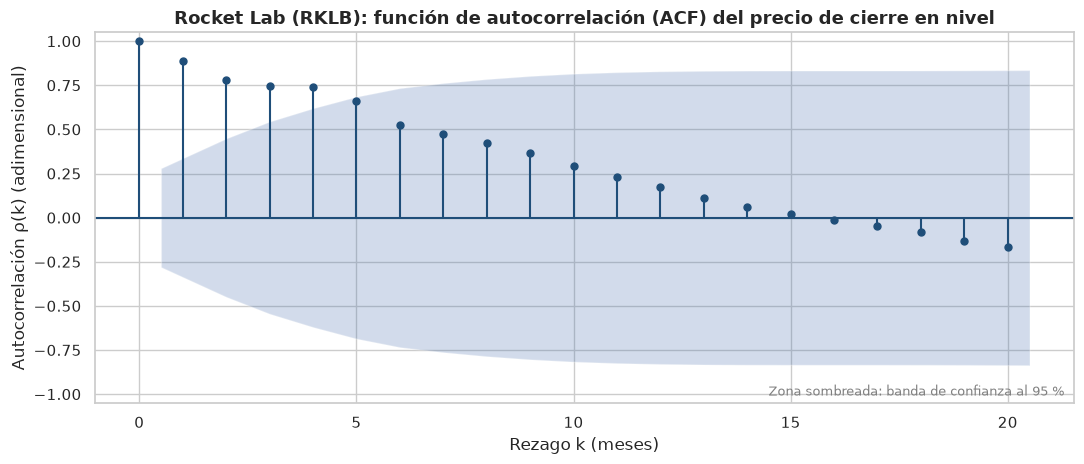

In [17]:
# Con 49 observaciones (48 cambios) se usan 20 rezagos (PACF de statsmodels exige nlags < n/2 = 24). Los rezagos lejanos se estiman con pocos pares: se enfatizan los primeros.
NLAGS = 20
def acf_tabla(x, nlags=NLAGS):
    a, ci = acf(x, nlags=nlags, alpha=0.05, fft=False)
    out = pd.DataFrame({"Rezago": range(nlags + 1), "ACF": a, "Banda inf.": ci[:, 0] - a, "Banda sup.": ci[:, 1] - a})
    out["Fuera de bandas"] = (out["Rezago"] > 0) & (out["ACF"].abs() > out["Banda sup."]); return out.round(3)
def pacf_tabla(x, nlags=NLAGS):
    a, ci = pacf(x, nlags=nlags, alpha=0.05, method="ywm")      # mismo método que plot_pacf(method="ywm")
    out = pd.DataFrame({"Rezago": range(nlags + 1), "PACF": a, "Banda inf.": ci[:, 0] - a, "Banda sup.": ci[:, 1] - a})
    out["Fuera de bandas"] = (out["Rezago"] > 0) & (out["PACF"].abs() > out["Banda sup."]); return out.round(3)

ac_n = acf_tabla(serie); ac_n.to_csv("tablas/t11_acf_nivel.csv", index=False); display(ac_n.style.hide(axis="index"))
fig, ax = plt.subplots(figsize=(11, 4.8))
plot_acf(serie, lags=NLAGS, alpha=0.05, ax=ax, color=C_NIVEL, vlines_kwargs={"colors": C_NIVEL}, title=None)
ax.set(title="Rocket Lab (RKLB): función de autocorrelación (ACF) del precio de cierre en nivel", xlabel="Rezago k (meses)", ylabel="Autocorrelación ρ(k) (adimensional)", ylim=(-1.05, 1.05))
ax.text(0.99, 0.02, "Zona sombreada: banda de confianza al 95 %", transform=ax.transAxes, ha="right", fontsize=9, color=C_REF)
guarda(fig, "fig_11_acf_nivel")
R.update(acf_nivel=ac_n.to_dict("records"), banda_nivel=float(ac_n.loc[1, "Banda sup."]), acf_nivel_fuera=ac_n.loc[ac_n["Fuera de bandas"], "Rezago"].tolist(), NLAGS=NLAGS,
         acf_nivel_pos=int((ac_n.loc[1:, "ACF"] > 0).sum()), acf_nivel_neg=int((ac_n.loc[1:, "ACF"] < 0).sum()))

### Respuestas

**¿Qué representa cada barra?**  
Cada barra es la autocorrelación muestral ρ(k) entre el precio de un mes y el de k meses antes (k en el eje horizontal). La altura indica magnitud y dirección; la zona sombreada es la banda de confianza al 95 % alrededor de cero.

**¿Qué rezagos sobrepasan las bandas?**  
Los **rezagos 1, 2, 3 y 4** (0.885, 0.779, 0.748 y 0.739; la banda va de ±0.280 en el rezago 1 a ±0.620 en el 4). Desde el rezago 5 (0.662) las barras quedan dentro porque las bandas se ensanchan (±0.685).

**¿Predominan autocorrelaciones positivas o negativas?**  
Positivas: 15 de los 20 rezagos son positivos (rezagos 1 a 15) y las negativas aparecen solo del 16 al 20 y son pequeñas (entre -0.011 y -0.167).

**¿Disminuyen conforme aumenta el rezago?**  
Sí, pero **lentamente**: 0.885 (rezago 1), 0.523 (rezago 6), 0.295 (rezago 10), 0.173 (rezago 12) y cerca de cero en el rezago 15 (0.018).

**¿Qué patrón general observan?**  
Un **decaimiento lento y suave desde valores muy altos**, típico de una serie con tendencia y nivel cambiante (no estacionaria en nivel): la persistencia es alta. La prueba de Ljung-Box con 10 rezagos lo confirma (Q = 212.8, p < 0.0001).

**¿Qué significa que una barra quede dentro de las bandas?**  
Que esa autocorrelación **no se distingue estadísticamente de cero** al 95 %; no demuestra que sea cero. Con solo 49 observaciones las bandas son anchas (±0.280 a ±0.83), por lo que hay poca potencia, sobre todo en los rezagos lejanos, que se calculan con pocos pares.

## 12. Correlograma PACF en nivel

Rezago,PACF,Banda inf.,Banda sup.,Fuera de bandas
0,1.000000,0.000000,0.000000,False
1,0.885000,-0.280000,0.280000,True
2,-0.017000,-0.280000,0.280000,False
3,0.287000,-0.280000,0.280000,True
4,0.111000,-0.280000,0.280000,False
5,-0.217000,-0.280000,0.280000,False
6,-0.334000,-0.280000,0.280000,True
7,0.227000,-0.280000,0.280000,False
8,-0.237000,-0.280000,0.280000,False
9,0.133000,-0.280000,0.280000,False


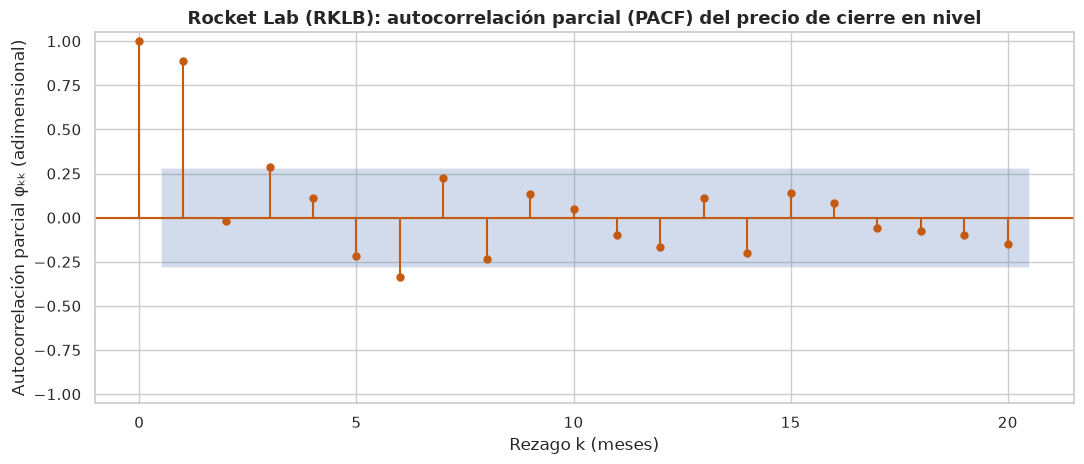

Rezago,ACF,PACF,|ACF| − |PACF|
1,0.885000,0.885000,0.000000
2,0.779000,-0.017000,0.762000
3,0.748000,0.287000,0.461000
4,0.739000,0.111000,0.628000
5,0.662000,-0.217000,0.445000
6,0.523000,-0.334000,0.189000
7,0.474000,0.227000,0.247000
8,0.424000,-0.237000,0.187000
9,0.366000,0.133000,0.233000
10,0.295000,0.049000,0.246000


In [18]:
pa_n = pacf_tabla(serie); pa_n.to_csv("tablas/t12_pacf_nivel.csv", index=False); display(pa_n.style.hide(axis="index"))
fig, ax = plt.subplots(figsize=(11, 4.8))
plot_pacf(serie, lags=NLAGS, alpha=0.05, ax=ax, method="ywm", color=C_ALT, vlines_kwargs={"colors": C_ALT}, title=None)
ax.set(title="Rocket Lab (RKLB): autocorrelación parcial (PACF) del precio de cierre en nivel", xlabel="Rezago k (meses)", ylabel="Autocorrelación parcial φₖₖ (adimensional)", ylim=(-1.05, 1.05))
guarda(fig, "fig_12_pacf_nivel")

cmp_n = pd.DataFrame({"Rezago": range(1, NLAGS + 1), "ACF": ac_n["ACF"][1:].values, "PACF": pa_n["PACF"][1:].values})
cmp_n["|ACF| − |PACF|"] = (cmp_n["ACF"].abs() - cmp_n["PACF"].abs()).round(3); cmp_n.to_csv("tablas/t12_acf_vs_pacf_nivel.csv", index=False); display(cmp_n.head(12).style.hide(axis="index"))
R.update(pacf_nivel=pa_n.to_dict("records"), pacf_nivel_fuera=pa_n.loc[pa_n["Fuera de bandas"], "Rezago"].tolist(), banda_pacf_nivel=float(pa_n.loc[1, "Banda sup."]))

### Respuestas

**¿Qué rezagos destacan?**  
Fuera de las bandas (±0.280) quedan el **rezago 1** (0.885, de lejos el dominante), el rezago 3 (0.287, apenas fuera) y el rezago 6 (-0.334, negativo).

**¿Coinciden con ACF?**  
Solo en parte. La ACF tiene fuera de bandas los rezagos 1 a 4; la PACF, los rezagos 1, 3 y 6. Coinciden en el rezago 1, que es el fundamental. Los rezagos 2 y 4 destacan en la ACF pero no en la PACF.

**¿Existe ACF alta pero PACF considerablemente menor?**  
Sí. Rezago 2: ACF 0.779 vs PACF -0.017; rezago 4: 0.739 vs 0.111; rezago 3: 0.748 vs 0.287.

**¿Cómo interpretan ese caso?**  
La ACF mide la asociación total y arrastra el efecto en cadena: como cada precio depende del anterior, el de hace 2 o 4 meses parece relacionado con el actual aunque solo lo esté a través del mes inmediato. Al controlar los rezagos intermedios, la relación **directa** con el precio de hace 2 meses es prácticamente nula (-0.017). La persistencia temporal de RKLB se concentra en el mes anterior. Los rezagos 3 y 6 de la PACF son marginales: al evaluar 20 rezagos al 5 % se espera ≈ 1 «falso positivo», por lo que no se interpretan como ciclos reales.

**¿Qué información adicional aporta PACF?**  
Separa la dependencia **directa** de la acumulada. Aquí sugiere que casi toda la dependencia del nivel es de primer orden con coeficiente cercano a 1, comportamiento parecido a una caminata aleatoria, lo que es una pista para el modelado futuro y no un modelo estimado.

## 13. ACF y PACF de la serie transformada (cambio logarítmico, % mensual)

ACF del cambio logarítmico:


Rezago,ACF,Banda inf.,Banda sup.,Fuera de bandas
0,1.000000,0.000000,0.000000,False
1,0.034000,-0.283000,0.283000,False
2,-0.051000,-0.283000,0.283000,False
3,-0.200000,-0.284000,0.284000,False
4,-0.010000,-0.295000,0.295000,False
5,0.082000,-0.295000,0.295000,False
6,-0.033000,-0.297000,0.297000,False
7,0.007000,-0.297000,0.297000,False
8,-0.009000,-0.297000,0.297000,False
9,0.033000,-0.297000,0.297000,False


PACF del cambio logarítmico:


Rezago,PACF,Banda inf.,Banda sup.,Fuera de bandas
0,1.000000,0.000000,0.000000,False
1,0.034000,-0.283000,0.283000,False
2,-0.052000,-0.283000,0.283000,False
3,-0.197000,-0.283000,0.283000,False
4,-0.000000,-0.283000,0.283000,False
5,0.066000,-0.283000,0.283000,False
6,-0.080000,-0.283000,0.283000,False
7,0.014000,-0.283000,0.283000,False
8,0.017000,-0.283000,0.283000,False
9,0.012000,-0.283000,0.283000,False


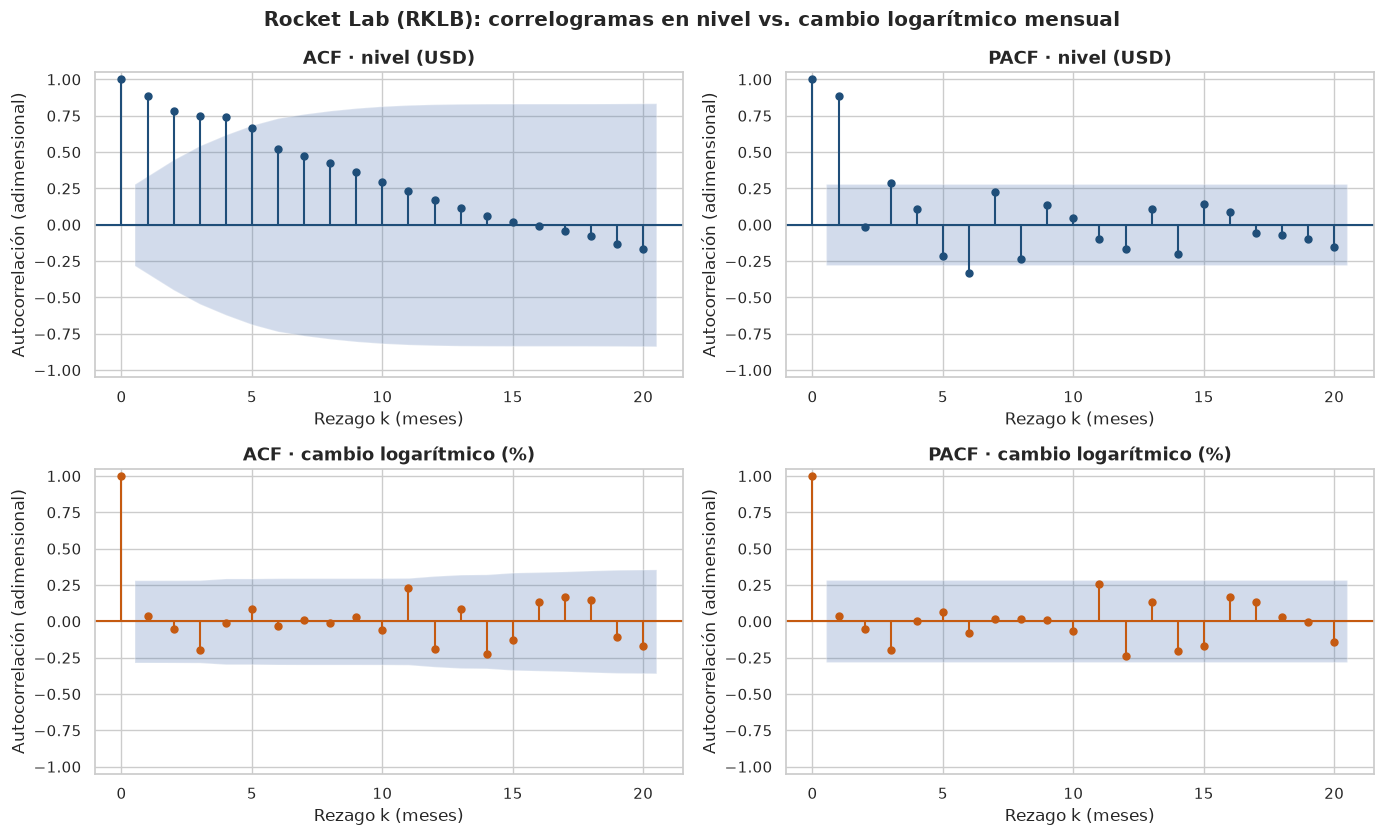

Rezago,ACF nivel,ACF cambio log,PACF nivel,PACF cambio log
1,0.885000,0.034000,0.885000,0.034000
2,0.779000,-0.051000,-0.017000,-0.052000
3,0.748000,-0.200000,0.287000,-0.197000
4,0.739000,-0.010000,0.111000,-0.000000
5,0.662000,0.082000,-0.217000,0.066000
6,0.523000,-0.033000,-0.334000,-0.080000
7,0.474000,0.007000,0.227000,0.014000
8,0.424000,-0.009000,-0.237000,0.017000
9,0.366000,0.033000,0.133000,0.012000
10,0.295000,-0.060000,0.049000,-0.066000


Ljung-Box (10 rezagos)  nivel: Q = 212.8, p = 0.0000 | cambio log: Q = 3.1, p = 0.980
ADF (AIC, máx. 4 rezagos)  nivel: p = 0.840 | cambio log: p = 0.0000   (orientativo; n pequeño)
Suma de |ACF| rezagos 1-20: nivel = 6.92 | cambio log = 2.10
Rezagos fuera de bandas -> ACF nivel: [1, 2, 3, 4] | PACF nivel: [1, 3, 6] | ACF cambio log: [] | PACF cambio log: []


In [19]:
ac_r = acf_tabla(r); pa_r = pacf_tabla(r)
ac_r.to_csv("tablas/t13_acf_retorno.csv", index=False); pa_r.to_csv("tablas/t13_pacf_retorno.csv", index=False)
print("ACF del cambio logarítmico:"); display(ac_r.head(13).style.hide(axis="index")); print("PACF del cambio logarítmico:"); display(pa_r.head(13).style.hide(axis="index"))

fig, axs = plt.subplots(2, 2, figsize=(14, 8.5))
plot_acf(serie, lags=NLAGS, ax=axs[0, 0], color=C_NIVEL, vlines_kwargs={"colors": C_NIVEL}, title=None)
plot_pacf(serie, lags=NLAGS, ax=axs[0, 1], method="ywm", color=C_NIVEL, vlines_kwargs={"colors": C_NIVEL}, title=None)
plot_acf(r, lags=NLAGS, ax=axs[1, 0], color=C_ALT, vlines_kwargs={"colors": C_ALT}, title=None)
plot_pacf(r, lags=NLAGS, ax=axs[1, 1], method="ywm", color=C_ALT, vlines_kwargs={"colors": C_ALT}, title=None)
for ax, tt in zip(axs.ravel(), ["ACF · nivel (USD)", "PACF · nivel (USD)", "ACF · cambio logarítmico (%)", "PACF · cambio logarítmico (%)"]):
    ax.set(title=tt, xlabel="Rezago k (meses)", ylabel="Autocorrelación (adimensional)", ylim=(-1.05, 1.05))
fig.suptitle("Rocket Lab (RKLB): correlogramas en nivel vs. cambio logarítmico mensual", fontweight="bold"); guarda(fig, "fig_13_acf_pacf_comparacion")

for nombre, fn, tt, yl in [("fig_13_acf_retorno", plot_acf, "Rocket Lab (RKLB): ACF del cambio logarítmico mensual (%)", "Autocorrelación ρ(k) (adimensional)"),
                           ("fig_13_pacf_retorno", plot_pacf, "Rocket Lab (RKLB): PACF del cambio logarítmico mensual (%)", "Autocorrelación parcial φₖₖ (adimensional)")]:
    fig, ax = plt.subplots(figsize=(11, 4.5)); kw = {"method": "ywm"} if fn is plot_pacf else {}
    fn(r, lags=NLAGS, ax=ax, color=C_ALT, vlines_kwargs={"colors": C_ALT}, title=None, **kw)
    ax.set(title=tt, xlabel="Rezago k (meses)", ylabel=yl, ylim=(-1.05, 1.05)); fig.tight_layout(); fig.savefig(f"figuras/{nombre}.png", dpi=150, bbox_inches="tight"); plt.close(fig)

comp_ac = pd.DataFrame({"Rezago": range(1, NLAGS + 1), "ACF nivel": ac_n["ACF"][1:].values, "ACF cambio log": ac_r["ACF"][1:].values,
                        "PACF nivel": pa_n["PACF"][1:].values, "PACF cambio log": pa_r["PACF"][1:].values}).round(3)
comp_ac.to_csv("tablas/t13_comparacion_acf_pacf.csv", index=False); display(comp_ac.head(12).style.hide(axis="index"))
lb_n = acorr_ljungbox(serie, lags=[10], return_df=True); lb_r = acorr_ljungbox(r, lags=[10], return_df=True)
adf_n = adfuller(serie, maxlag=4, autolag="AIC"); adf_r = adfuller(r, maxlag=4, autolag="AIC")
print(f"Ljung-Box (10 rezagos)  nivel: Q = {lb_n['lb_stat'].iloc[0]:.1f}, p = {lb_n['lb_pvalue'].iloc[0]:.4f} | cambio log: Q = {lb_r['lb_stat'].iloc[0]:.1f}, p = {lb_r['lb_pvalue'].iloc[0]:.3f}")
print(f"ADF (AIC, máx. 4 rezagos)  nivel: p = {adf_n[1]:.3f} | cambio log: p = {adf_r[1]:.4f}   (orientativo; n pequeño)")
print(f"Suma de |ACF| rezagos 1-{NLAGS}: nivel = {comp_ac['ACF nivel'].abs().sum():.2f} | cambio log = {comp_ac['ACF cambio log'].abs().sum():.2f}")
print(f"Rezagos fuera de bandas -> ACF nivel: {ac_n.loc[ac_n['Fuera de bandas'],'Rezago'].tolist()} | PACF nivel: {pa_n.loc[pa_n['Fuera de bandas'],'Rezago'].tolist()} | ACF cambio log: {ac_r.loc[ac_r['Fuera de bandas'],'Rezago'].tolist()} | PACF cambio log: {pa_r.loc[pa_r['Fuera de bandas'],'Rezago'].tolist()}")
R.update(acf_ret=ac_r.to_dict("records"), pacf_ret=pa_r.to_dict("records"), acf_ret_fuera=ac_r.loc[ac_r["Fuera de bandas"], "Rezago"].tolist(), pacf_ret_fuera=pa_r.loc[pa_r["Fuera de bandas"], "Rezago"].tolist(),
         banda_ret=float(ac_r.loc[1, "Banda sup."]), lb_n_p=float(lb_n["lb_pvalue"].iloc[0]), lb_r_p=float(lb_r["lb_pvalue"].iloc[0]), lb_n_q=float(lb_n["lb_stat"].iloc[0]), lb_r_q=float(lb_r["lb_stat"].iloc[0]),
         adf_n_p=float(adf_n[1]), adf_r_p=float(adf_r[1]), sum_abs_n=float(comp_ac["ACF nivel"].abs().sum()), sum_abs_r=float(comp_ac["ACF cambio log"].abs().sum()),
         comp_ac=comp_ac.to_dict("records"))

In [20]:
# Chequeos de robustez del diagnóstico: (a) sin el mes parcial oct-2026; (b) solo con Train (lo que se usaría para modelar sin «mirar» Test)
def lag1(x): return x.autocorr(1)
r_sin = r.iloc[:-1]; s_sin = serie.iloc[:-1]
print(f"(a) Sin oct-2026 | autocorr. lag 1 nivel: {lag1(s_sin):.3f} (con: {lag1(serie):.3f}) | cambio log: {lag1(r_sin):.3f} (con: {lag1(r):.3f}) | media cambio log: {r_sin.mean():+.2f}% (con: {r.mean():+.2f}%)")
tr_s = train; tr_r = lr.dropna().loc[:train.index[-1]]
print(f"(b) Solo Train (n={len(tr_s)}) | autocorr. lag 1 nivel: {lag1(tr_s):.3f} | cambio log: {lag1(tr_r):.3f} | ACF cambio log lag 1-3: {np.round(acf(tr_r, nlags=3, fft=False)[1:], 3).tolist()}")
R.update(lag1_nivel_sin=float(lag1(s_sin)), lag1_ret_sin=float(lag1(r_sin)), media_ret_sin=float(r_sin.mean()), lag1_nivel_tr=float(lag1(tr_s)), lag1_ret_tr=float(lag1(tr_r)), lag1_nivel=float(lag1(serie)), lag1_ret=float(lag1(r)))

(a) Sin oct-2026 | autocorr. lag 1 nivel: 0.903 (con: 0.906) | cambio log: 0.035 (con: 0.034) | media cambio log: +5.57% (con: +5.47%)
(b) Solo Train (n=39) | autocorr. lag 1 nivel: 0.920 | cambio log: -0.021 | ACF cambio log lag 1-3: [-0.021, 0.159, -0.225]


### Respuestas

**¿La dependencia temporal se ve igual que en nivel?**  
No. En nivel la ACF es 0.885 en el rezago 1 y decae lentamente; en el cambio logarítmico es 0.034 en el rezago 1 y las barras son pequeñas y de signo alternante, sin forma. La PACF del nivel tiene una barra dominante (0.885); la del cambio logarítmico no tiene ninguna.

**¿En cuál hay mayor persistencia?**  
En el **nivel**. La suma de |ACF| en los 20 rezagos es de 6.92 en nivel y de 2.10 en cambio logarítmico, valor similar al ≈ 2.30 que se esperaría de ruido blanco con 48 datos. Ljung-Box (10 rezagos): p < 0.0001 en nivel y p = 0.980 en cambio logarítmico.

**¿Cambian las barras que superan las bandas?**  
Sí. En nivel superan las bandas los rezagos 1–4 (ACF) y 1, 3 y 6 (PACF); en el cambio logarítmico **ninguna barra** supera las bandas (±0.283), ni en ACF ni en PACF. Las más cercanas son el rezago 11 (ACF 0.229; PACF 0.260) y el 12 (ACF -0.192; PACF -0.239), que sugerirían algo anual, pero quedan dentro y no se pueden distinguir de ruido.

**¿Qué cambia en el patrón general?**  
Se pasa de un decaimiento lento desde 0.885, con persistencia fuerte, a un patrón de ruido blanco aparente: autocorrelaciones pequeñas alrededor de cero, sin decaimiento ni cortes definidos. Esto es consistente con que el logaritmo del precio se comporte como una caminata aleatoria, aunque el correlograma por sí solo no lo prueba. Los resultados casi no cambian si se excluye el mes parcial (autocorr. rezago 1 de 0.035) o si se usa solo Train (nivel 0.920; cambio logarítmico -0.021).

**¿El correlograma por sí solo permite afirmar estacionariedad?**  
**No.** (1) El correlograma solo mide dependencia lineal; la estacionariedad también exige media y varianza constantes en el tiempo. (2) En el cambio logarítmico la ACF es casi nula, pero la volatilidad no es constante: su desviación móvil de 6 meses va de 11.1 % (jul-2024) a 44.6 % (abr-2025), y por año de 20.0 % a 30.1 %. (3) Con 48 datos las bandas son amplias. (4) Se necesita además la inspección de la gráfica y pruebas formales (ADF, KPSS, Phillips-Perron); la ADF aquí es solo orientativa (p = 0.840 en nivel y p < 0.001 en cambio logarítmico).

## 14. Observaciones atípicas, episodios y posibles cambios importantes

,Cierre (USD),Cambio simple (%),Cambio log (%),z,z robusto,Volumen (M acc.)
Fecha,,,,,,
2024-11,27.28,154.95,93.59,3.39,3.89,600.43
2026-07,64.95,-36.10,-44.79,-1.93,-2.16,423.37
2026-05,143.48,73.89,55.33,1.92,2.22,603.74
2025-11,42.14,-33.09,-40.18,-1.76,-1.96,351.50
2025-12,69.76,65.54,50.41,1.73,2.00,576.79
2023-09,4.38,-30.59,-36.51,-1.62,-1.80,106.73
2025-02,20.49,-29.47,-34.91,-1.55,-1.73,388.40
2026-06,101.65,-29.15,-34.47,-1.54,-1.71,634.08


Meses con |z|>2: 1 | |z|>1.5: 8 de 48


,inicio,fin,largo,signo,acumulado
Cambio log (%),,,,,
8,may-2024,nov-2024,7,1.0,198.2
12,abr-2025,ago-2025,5,1.0,100.0
7,ene-2024,abr-2024,4,-1.0,-38.6
4,may-2023,jul-2023,3,1.0,63.1


,n,media,desv_est,maximo,minimo
Fecha,,,,,
2022,2,-15.01,6.29,-10.56,-19.46
2023,12,3.19,20.00,27.63,-36.51
2024,12,12.73,30.15,93.59,-13.12
2025,12,8.40,26.88,50.41,-40.18
2026,10,0.10,28.72,55.33,-44.79


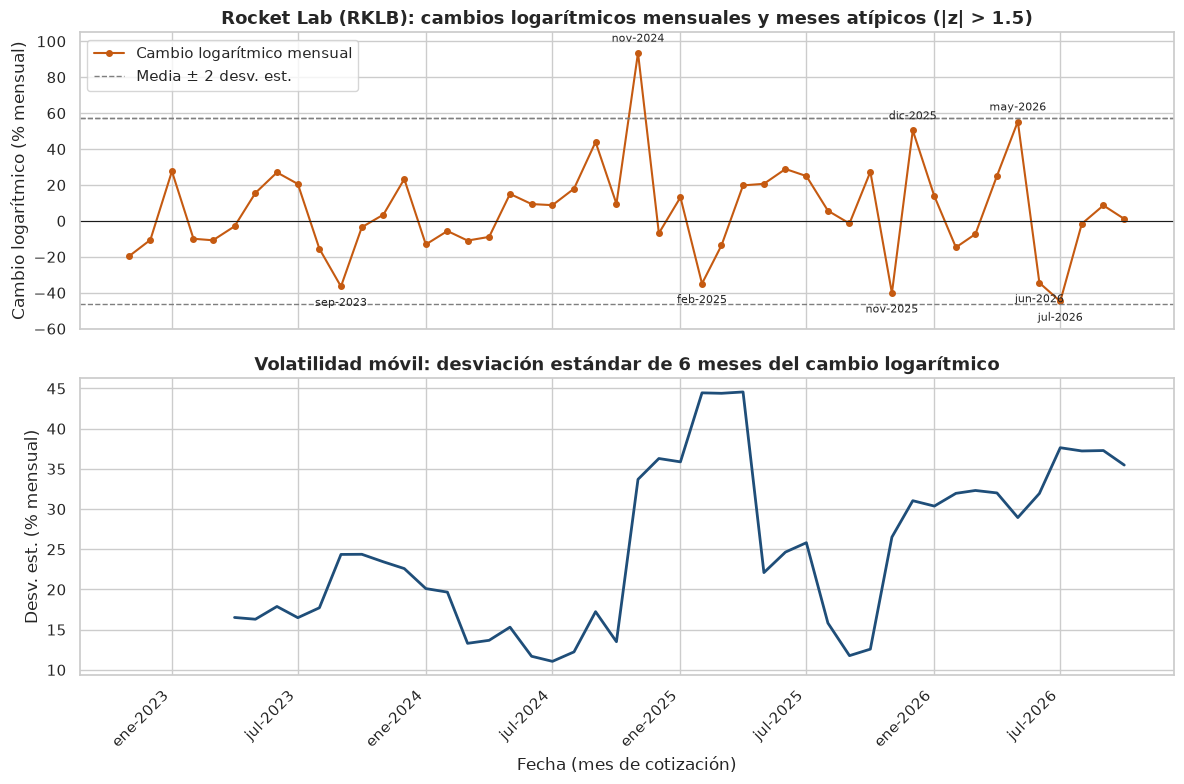

Volumen mensual: mediana 308 M; mín 50 M (abr-2023); máx 634 M (jun-2026)
Corr(|cambio log|, volumen) sin el mes parcial: 0.44


In [21]:
z = (r - r.mean()) / r.std()
mad = (r - r.median()).abs().median() * 1.4826; zr = (r - r.median()) / mad          # z robusto (mediana y MAD)
ep = pd.DataFrame({"Cierre (USD)": serie[r.index], "Cambio simple (%)": pct[r.index], "Cambio log (%)": r, "z": z, "z robusto": zr, "Volumen (M acc.)": df.set_index("Fecha")["Vol_M"][r.index]})
ep_top = ep[(ep["z"].abs() > 1.5)].sort_values("z", key=abs, ascending=False).round(2)
ep_top.index = ep_top.index.strftime("%Y-%m"); ep_top.to_csv("tablas/t14_episodios.csv"); display(ep_top)
print(f"Meses con |z|>2: {int((z.abs()>2).sum())} | |z|>1.5: {int((z.abs()>1.5).sum())} de {len(z)}")

# Rachas de meses consecutivos con el mismo signo
signo = np.sign(r); grupos = (signo != signo.shift()).cumsum()
rachas = r.groupby(grupos).agg(inicio=lambda s: s.index[0], fin=lambda s: s.index[-1], largo="size", signo=lambda s: np.sign(s.iloc[0]), acumulado=lambda s: s.sum())
rachas = rachas.sort_values("largo", ascending=False).head(4)
rachas["inicio"] = rachas["inicio"].map(fmt_fecha); rachas["fin"] = rachas["fin"].map(fmt_fecha); rachas["acumulado"] = rachas["acumulado"].round(1)
display(rachas)

# Volatilidad por año y móvil de 6 meses
vol_anual = r.groupby(r.index.year).agg(n="size", media="mean", desv_est="std", maximo="max", minimo="min").round(2)
vol_anual.to_csv("tablas/t14_volatilidad_anual.csv"); display(vol_anual)
vm = r.rolling(6).std()

fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axs[0].plot(r.index, r.values, marker="o", ms=4, color=C_ALT, label="Cambio logarítmico mensual")
axs[0].axhline(0, color="k", lw=0.8)
for k_, c_ in [(2, C_REF), (-2, C_REF)]: axs[0].axhline(r.mean() + k_ * r.std(), color=c_, ls="--", lw=1)
axs[0].axhline(r.mean() + 2 * r.std(), color=C_REF, ls="--", lw=1, label="Media ± 2 desv. est.")
for t_, v_ in r[z.abs() > 1.5].items(): axs[0].annotate(fmt_fecha(t_), (t_, v_), textcoords="offset points", xytext=(0, 8 if v_ > 0 else -14), ha="center", fontsize=8)
axs[0].set(title="Rocket Lab (RKLB): cambios logarítmicos mensuales y meses atípicos (|z| > 1.5)", ylabel="Cambio logarítmico (% mensual)", ylim=(-60, 105)); axs[0].legend(loc="upper left")
axs[1].plot(vm.index, vm.values, color=C_NIVEL, lw=2); axs[1].set(title="Volatilidad móvil: desviación estándar de 6 meses del cambio logarítmico", xlabel="Fecha (mes de cotización)", ylabel="Desv. est. (% mensual)")
eje_fechas(axs[1]); guarda(fig, "fig_14_episodios")
R.update(ep=ep_top.reset_index().rename(columns={"index": "Mes", "Fecha": "Mes"}).to_dict("records"), n_z2=int((z.abs()>2).sum()), n_z15=int((z.abs()>1.5).sum()),
         vol_anual=vol_anual.reset_index().rename(columns={"index": "anio", "Fecha": "anio"}).to_dict("records"),
         rachas=rachas.reset_index(drop=True).to_dict("records"), vm_min=float(vm.min()), f_vm_min=str(vm.idxmin().date()), vm_max=float(vm.max()), f_vm_max=str(vm.idxmax().date()))
vol = df.set_index("Fecha")["Vol_M"]
print(f"Volumen mensual: mediana {vol.iloc[:-1].median():.0f} M; mín {vol.iloc[:-1].min():.0f} M ({fmt_fecha(vol.iloc[:-1].idxmin())}); máx {vol.max():.0f} M ({fmt_fecha(vol.idxmax())})")
print(f"Corr(|cambio log|, volumen) sin el mes parcial: {r.iloc[:-1].abs().corr(vol.iloc[1:-1]):.2f}")
R.update(vol_med_total=float(vol.iloc[:-1].median()), vol_max_total=float(vol.max()), f_vol_max=str(vol.idxmax().date()), corr_abs_vol=float(r.iloc[:-1].abs().corr(vol.iloc[1:-1])))

### Respuestas

**¿Observan uno o varios movimientos que sobresalgan claramente?**  
Sobresale **nov-2024** (+93.59 % logarítmico; z = 3.39), el único mes con |z| > 2. Siguen jul-2026 (-44.8 %, z = -1.93), may-2026 (+55.3 %, z = 1.92), nov-2025 (-40.2 %), dic-2025 (+50.4 %), sep-2023 (-36.5 %), feb-2025 (-34.9 %) y jun-2026 (-34.5 %): 8 de 48 meses tienen |z| > 1.5.

**¿Parece un solo punto atípico o un episodio de varios periodos?**  
Ambos. **nov-2024** es un punto extremo aislado, pero forma parte de un episodio mayor: 7 alzas consecutivas entre may-2024 y nov-2024 (+198.2 % logarítmico acumulado), tras el cual el precio se instaló en un rango más alto (nunca bajó de 17.88 USD): es un **posible cambio de nivel o de régimen**. Otros episodios: abr–ago-2025 (5 alzas, +100.0 %) y el ciclo may–jul-2026 (máximo de 143.48 USD y luego dos caídas seguidas, −50.9 % desde el pico). La volatilidad móvil muestra regímenes: calma en jul-2024 (11.1 %), pico en abr-2025 (44.6 %) y nivel alto (26–38 %) desde nov-2025.

**¿Eliminarían automáticamente esa observación? ¿Por qué?**  
No. Son precios reales, no errores de captura: el «% var.» de la fuente coincide con el cálculo y los cierres están dentro del rango del mes. Además, los meses extremos coinciden con volumen alto (nov-2024: 600.43 M; may-2026: 603.74 M; jun-2026: 634.08 M, frente a una mediana de 308.4 M; correlación entre |cambio logarítmico| y volumen = 0.44), consistente con eventos de mercado reales. Eliminarlos ocultaría justamente el riesgo de la acción. Antes de cualquier tratamiento habría que investigar la causa (noticias, resultados, lanzamientos), algo que esta base no permite identificar.

## 15. Conclusión diagnóstica integradora

### Respuestas

**1. ¿Cuáles son las principales características temporales de la serie?**  
RKLB tiene (a) **tendencia ascendente muy fuerte y casi exponencial** (de 5.09 a 70.46 USD; ≈ 8.2 % mensual compuesto en la tendencia log-lineal), con un máximo de 143.48 USD en may-2026 y una corrección posterior de 51 %; (b) **variabilidad creciente** con el nivel (desviación del precio de 1.07 USD en 2023 a 24.82 USD en 2026); (c) **alta persistencia en nivel** (autocorrelación de rezago 1 = 0.906); (d) **cambios mensuales muy grandes** (desviación del cambio logarítmico de 26.0 %); y (e) un **cambio de régimen** hacia precios altos desde nov-2024. No se observó estacionalidad.

**2. ¿Qué transformación modifica de manera más clara su comportamiento y por qué?**  
El **cambio logarítmico mensual** (el cambio simple se comporta casi igual, pero es asimétrico y no aditivo). Convierte una serie con tendencia en una que oscila alrededor de cero: la autocorrelación de rezago 1 cae de 0.906 a 0.034 y ADF (orientativa) pasa de p = 0.840 a p < 0.001. Además, expresa los movimientos en términos relativos, comparables entre 2023 y 2026. ln(Y) solo cambia la escala (autocorr. 0.977) y ΔY quita la tendencia pero conserva la heterocedasticidad (1.10 → 20.12 USD).

**3. ¿Qué revelan ACF y PACF sobre la dependencia temporal?**  
En nivel, la ACF muestra una dependencia fuerte y persistente: 0.885 en el rezago 1, rezagos 1–4 fuera de bandas y decaimiento lento hasta ≈ 0 en el rezago 15. La PACF revela que casi toda esa dependencia es **directa del mes anterior** (0.885); el efecto de rezagos 2–4 en la ACF es en cadena (PACF en el rezago 2 = -0.017). Esto es típico de una serie que se comporta como una caminata aleatoria: el mejor predictor del precio de un mes es el del mes anterior.

**4. ¿Cómo cambia esa dependencia al pasar del nivel a la serie transformada?**  
Desaparece casi por completo: el rezago 1 pasa de 0.885 a 0.034; de 4 barras de ACF y 3 de PACF fuera de bandas se pasa a ninguna; la suma de |ACF| baja de 6.92 a 2.10 (≈ ruido blanco) y Ljung-Box pasa de p < 0.0001 a p = 0.980. La dependencia lineal que quedaba era la de la tendencia, no un comportamiento predecible en los cambios.

**5. ¿Existen observaciones atípicas, episodios o posibles cambios importantes?**  
Sí. El mes atípico principal es **nov-2024** (+154.95 % simple; +93.59 % logarítmico; z = 3.39); también destacan may-2026 (+73.9 %), dic-2025 (+65.5 %), nov-2025 (−33.1 %), jun-2026 (−29.2 %) y jul-2026 (−36.1 %). Hay episodios de alzas consecutivas (may–nov-2024 y abr–ago-2025), un posible **cambio de nivel** tras nov-2024 y regímenes de volatilidad (calma en jul-2024 con 11.1 % y picos de hasta 44.6 % en abr-2025). Los meses extremos coinciden con volúmenes altos, por lo que parecen eventos reales y no errores.

**6. ¿Qué representación consideran más adecuada para continuar posteriormente con el modelado y por qué?**  
El **cambio logarítmico mensual**, 100·[ln(Yt) − ln(Yt−1)]: (i) elimina la tendencia sin perder interpretación económica (variación porcentual continua); (ii) su ACF/PACF no muestra dependencia significativa, lo que es apropiado como punto de partida; (iii) es aditivo, así que los pronósticos acumulados se convierten de vuelta a precio con la exponencial; y (iv) hace comparables 2023 y 2026. Dos advertencias para la siguiente etapa: la media mensual (5.47 %) no es distinguible de cero (t ≈ 1.46), así que la predicción de la media será difícil; y como la volatilidad cambia (11.1 %–44.6 %), conviene considerar un modelo de volatilidad condicional. Debe estimarse solo con Train (oct-2022–dic-2025) y evaluarse en Test.

**7. ¿Cuáles son las principales limitaciones de su diagnóstico?**  
(a) **Muestra corta**: 49 meses (48 cambios); las bandas de confianza son anchas (±0.28 a ±0.83) y los rezagos lejanos se estiman con pocos pares. (b) **20 rezagos evaluados al 5 %**: se espera ≈ 1 barra fuera por azar. (c) El último mes (oct-2026) es **parcial**. (d) Se usan datos de cierre mensual: se pierde la variación dentro del mes (por ejemplo, jul-2026 abrió en 101.2 y tocó 107.6 y 58.2 USD). (e) El diagnóstico es descriptivo: ADF y Ljung-Box son orientativas, sin pruebas formales de cambio estructural, KPSS ni heterocedasticidad (ARCH). (f) No se investigaron las causas de los episodios atípicos. (g) Train y Test pertenecen a regímenes de precio muy distintos (16.76 vs 81.00 USD) y Test tiene solo 10 meses. (h) El ACF se calculó con toda la muestra con fines de diagnóstico; en el modelado debe calcularse solo con Train. (i) Los resultados describen a RKLB en este periodo y no son generalizables.

In [22]:
R["lag1_nivel_ac"] = R["ac_nivel"][0]
json.dump(R, open("resultados.json", "w"), ensure_ascii=False, indent=1, default=str)
print("Resultados guardados en resultados.json (", len(R), "claves )")

Resultados guardados en resultados.json ( 156 claves )


---
## Fuentes y archivos
- **Datos:** archivo `Datos_historicos_RKLB.csv` («Datos históricos RKLB», precio mensual de Rocket Lab USA, Inc., Nasdaq: RKLB; oct-2022 a oct-2026), proporcionado por el equipo; consultado el 2 de octubre de 2026. Versión limpia y ordenada: `RKLB_base_limpia.csv`.
- **Indicaciones y rúbrica:** «Trabajo Final · Unidad 1 — Diagnóstico y preparación de una serie de tiempo» y su rúbrica de evaluación; Actividad 2 y Actividad 2-Parte II en Google Colab (Series de Tiempo Aplicadas a las Finanzas).
- **Software:** Python, pandas, NumPy, statsmodels (Seabold & Perktold, 2010), matplotlib, seaborn.